# 05 · Diagramas de persistencia por niño/día + bootstrap topológico

Este notebook analiza de forma individual las series temporales de los niños `ID1` a `ID20`.

La idea es construir, para cada niño y día, una pequeña nube de puntos en el espacio **valencia-arousal** usando las etapas disponibles de la exposición (`inicio`, `p1`, `p2`, `final`). Sobre cada nube se calcula persistencia H0 y después se comparan días consecutivos para detectar rangos donde la forma del día cambia de manera marcada.

El enfoque es descriptivo: buscamos cambios topológicos/geométricos robustos y luego rastreamos de dónde vienen revisando etapas, conducta y comentarios.

## 1. Librerías, rutas y configuración

In [1]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.optimize import linear_sum_assignment

DATA_CANDIDATES = [
    Path("DataFrameBabyFaceValidacion.xlsx"),
    Path("extracted/DataFrameBabyFaceValidacion.xlsx"),
    Path("/mnt/data/DataFrameBabyFaceValidacion.xlsx"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró DataFrameBabyFaceValidacion.xlsx")

OUTPUT_DIR = Path("persistence_child_day_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RNG = np.random.default_rng(42)
TARGET_IDS = [f"ID{i}" for i in range(1, 21)]
N_BOOT = 250

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print(f"Base de datos: {DATA_PATH.resolve()}")
print(f"Carpeta de salidas: {OUTPUT_DIR.resolve()}")

Base de datos: /home/jorge/Projects/topo/babyFace/DataFrameBabyFaceValidacion.xlsx
Carpeta de salidas: /home/jorge/Projects/topo/babyFace/persistence_child_day_outputs


## 2. Limpieza y construcción de nubes valencia-arousal por día

Cada fila original contiene varias mediciones afectivas del mismo día/exposición. Para cada fila se arma una nube con los pares disponibles:

- `inicio`
- `p1_before`, `p1_during`, `p1_after`
- `p2_before`, `p2_during`, `p2_after`
- `final`

Se conservan solo pares completos de valencia y arousal.

In [2]:
MISSING_TOKENS = {'', '-', 'NA', 'NA ', 'N/A', 'nan', 'NaN', 'FIT_FAILED', 'FIT FAILED', 'FIND_FAILED', 'FIND FAILED', 'S/I', None}
BEHAVIOR_COLS = ['rechaza', 'llora', 'toca', 'prueba', 'consume']
STAGES = [
    ('inicio', 'valence_inicio', 'arousal_inicio'),
    ('p1_before', 'valence_p1_before', 'arousal_p1_before'),
    ('p1_during', 'valence_p1_during', 'arousal_p1_during'),
    ('p1_after', 'valence_p1_after', 'arousal_p1_after'),
    ('p2_before', 'valence_p2_before', 'arousal_p2_before'),
    ('p2_during', 'valence_p2_during', 'arousal_p2_during'),
    ('p2_after', 'valence_p2_after', 'arousal_p2_after'),
    ('final', 'valence_final', 'arousal_final'),
]
AFFECT_COLS = [c for _, v, a in STAGES for c in (v, a)]


def normalize_missing(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str) and x.strip() in MISSING_TOKENS:
        return np.nan
    return x


def parse_day_order(x):
    """Orden temporal flexible: 6.1 queda 6.1; 2E queda 2.0."""
    x = normalize_missing(x)
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(',', '.')
    m = re.search(r"\d+(?:\.\d+)?", s)
    return float(m.group(0)) if m else np.nan


def stage_cloud(row):
    rows = []
    for stage, vcol, acol in STAGES:
        v = row.get(vcol, np.nan)
        a = row.get(acol, np.nan)
        if pd.notna(v) and pd.notna(a):
            rows.append({'stage': stage, 'valence': float(v), 'arousal': float(a)})
    return pd.DataFrame(rows, columns=['stage', 'valence', 'arousal'])

raw = pd.read_excel(DATA_PATH, dtype=object)
df = raw.copy()
for col in AFFECT_COLS + BEHAVIOR_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].map(normalize_missing), errors='coerce')
df['dia_order'] = df['dia'].map(parse_day_order)
df['dia_label'] = df['dia'].astype(str)
df = df[df['id'].isin(TARGET_IDS)].copy().sort_values(['id', 'dia_order', 'dia_label']).reset_index(drop=True)
df['exposicion_orden'] = df.groupby('id').cumcount() + 1

coverage_rows = []
clouds = {}
for idx, row in df.iterrows():
    cloud = stage_cloud(row)
    key = (row['id'], row['exposicion_orden'])
    clouds[key] = cloud
    coverage_rows.append({
        'id': row['id'],
        'exposicion_orden': row['exposicion_orden'],
        'dia': row['dia'],
        'dia_order': row['dia_order'],
        'n_puntos_nube': len(cloud),
        'stages_disponibles': ', '.join(cloud['stage'].tolist()) if len(cloud) else '',
        'consume': row.get('consume', np.nan),
        'rechaza': row.get('rechaza', np.nan),
        'comentarios': row.get('comentarios', np.nan),
    })
coverage = pd.DataFrame(coverage_rows)
coverage.to_csv(OUTPUT_DIR / '05_cobertura_nubes_por_nino_dia.csv', index=False)
display(coverage.head(20))

display(coverage.groupby('id')['n_puntos_nube'].describe().round(2))

,id,exposicion_orden,dia,dia_order,n_puntos_nube,stages_disponibles,consume,rechaza,comentarios
0,ID1,1,1,1.0000,8,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN
1,ID1,2,2,2.0000,8,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN
2,ID1,3,3,3.0000,8,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN
3,ID1,4,4,4.0000,5,"p1_after, p2_before, p2_during, p2_after, final",1.0000,0.0000,"Sólo lo consume la 1ra vez, 2da sólo pruba"
4,ID1,5,5,5.0000,8,"inicio, p1_before, p1_during, p1_after, p2_bef...",0.0000,0.0000,NaN
5,ID1,6,6,6.0000,7,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN
6,ID1,7,7,7.0000,8,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,Lo consume sólo la 2da vez
7,ID1,8,8,8.0000,7,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN
8,ID1,9,9,9.0000,5,"inicio, p1_before, p2_before, p2_during, p2_after",0.0000,0.0000,"Primeras 2 veces lo prueba, al 4to intento lo ..."
9,ID1,10,10,10.0000,7,"inicio, p1_before, p1_during, p1_after, p2_bef...",1.0000,0.0000,NaN


,count,mean,std,min,25%,50%,75%,max
id,,,,,,,,
ID1,15.0000,7.0700,1.1600,5.0000,7.0000,7.0000,8.0000,8.0000
ID10,24.0000,4.4600,2.6700,0.0000,2.0000,5.0000,7.2500,8.0000
ID11,20.0000,6.3500,1.6300,4.0000,5.0000,6.0000,8.0000,8.0000
ID12,29.0000,4.7900,1.8400,1.0000,4.0000,4.0000,6.0000,8.0000
ID13,8.0000,3.1200,2.2300,2.0000,2.0000,2.0000,2.7500,8.0000
ID14,23.0000,4.2600,2.0500,1.0000,2.5000,5.0000,5.0000,8.0000
ID15,21.0000,7.5200,1.0800,5.0000,8.0000,8.0000,8.0000,8.0000
ID16,27.0000,3.5600,1.6300,1.0000,2.0000,4.0000,4.0000,7.0000
ID17,13.0000,2.9200,2.1800,0.0000,2.0000,2.0000,5.0000,8.0000


## 3. Diagramas de persistencia H0 por niño/día

Con pocos puntos por día, el rasgo más estable es **H0**: cómo se conectan componentes al aumentar la escala de Vietoris-Rips. Para H0, las muertes se obtienen con las aristas del árbol de expansión mínima.

Interpretación práctica:

- Muertes pequeñas: etapas afectivas cercanas entre sí.
- Muertes grandes: alguna etapa está lejos del resto; posible cambio fuerte dentro de ese día.
- Cambios grandes entre diagramas de días consecutivos: cambio en la geometría afectiva de la exposición.

In [3]:
def h0_deaths(points):
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n <= 1:
        return np.array([], dtype=float)
    D = squareform(pdist(points))
    mst = minimum_spanning_tree(D).toarray()
    deaths = np.sort(mst[mst > 0])
    return deaths.astype(float)


def cloud_stats(cloud):
    if len(cloud) == 0:
        return {'centroid_valence': np.nan, 'centroid_arousal': np.nan, 'diameter': np.nan, 'path_stage_length': np.nan}
    pts = cloud[['valence','arousal']].to_numpy(float)
    centroid = pts.mean(axis=0)
    diameter = float(pdist(pts).max()) if len(pts) > 1 else 0.0
    path_len = float(np.sum(np.linalg.norm(np.diff(pts, axis=0), axis=1))) if len(pts) > 1 else 0.0
    return {
        'centroid_valence': centroid[0],
        'centroid_arousal': centroid[1],
        'diameter': diameter,
        'path_stage_length': path_len,
    }

summary_rows = []
diagrams = {}
for _, row in coverage.iterrows():
    key = (row['id'], row['exposicion_orden'])
    cloud = clouds[key]
    pts = cloud[['valence','arousal']].to_numpy(float) if len(cloud) else np.empty((0,2))
    deaths = h0_deaths(pts)
    diagrams[key] = deaths
    stats = cloud_stats(cloud)
    summary_rows.append({
        'id': row['id'],
        'exposicion_orden': row['exposicion_orden'],
        'dia': row['dia'],
        'dia_order': row['dia_order'],
        'n_puntos': len(cloud),
        'n_muertes_H0': len(deaths),
        'h0_muerte_max': np.max(deaths) if len(deaths) else np.nan,
        'h0_muerte_media': np.mean(deaths) if len(deaths) else np.nan,
        'h0_muerte_mediana': np.median(deaths) if len(deaths) else np.nan,
        **stats,
    })

diag_summary = pd.DataFrame(summary_rows)
diag_summary.to_csv(OUTPUT_DIR / '05_resumen_diagramas_h0_por_nino_dia.csv', index=False)
display(diag_summary.head(20).round(4))

,id,exposicion_orden,dia,dia_order,n_puntos,n_muertes_H0,h0_muerte_max,h0_muerte_media,h0_muerte_mediana,centroid_valence,centroid_arousal,diameter,path_stage_length
0,ID1,1,1,1.0000,8,7,0.4633,0.1180,0.0286,0.2346,0.5598,0.7813,1.0359
1,ID1,2,2,2.0000,8,7,0.4132,0.1698,0.1342,0.2620,0.5569,0.6853,1.5844
2,ID1,3,3,3.0000,8,7,0.1770,0.0913,0.0770,0.1600,0.6923,0.4119,0.7366
3,ID1,4,4,4.0000,5,4,0.1723,0.0988,0.0865,0.2093,0.6063,0.3104,0.6157
4,ID1,5,5,5.0000,8,7,0.1542,0.0723,0.0515,0.1720,0.5998,0.3325,0.7424
5,ID1,6,6,6.0000,7,6,0.1390,0.0665,0.0642,0.2539,0.5835,0.2170,0.4957
6,ID1,7,7,7.0000,8,7,0.2291,0.0984,0.0596,0.2530,0.7845,0.4038,0.9098
7,ID1,8,8,8.0000,7,6,0.1359,0.0702,0.0628,0.1547,0.5811,0.2719,0.5230
8,ID1,9,9,9.0000,5,4,0.0992,0.0628,0.0599,0.1714,0.5717,0.1618,0.2807
9,ID1,10,10,10.0000,7,6,0.1770,0.0849,0.0675,0.1559,0.5406,0.3371,0.6405


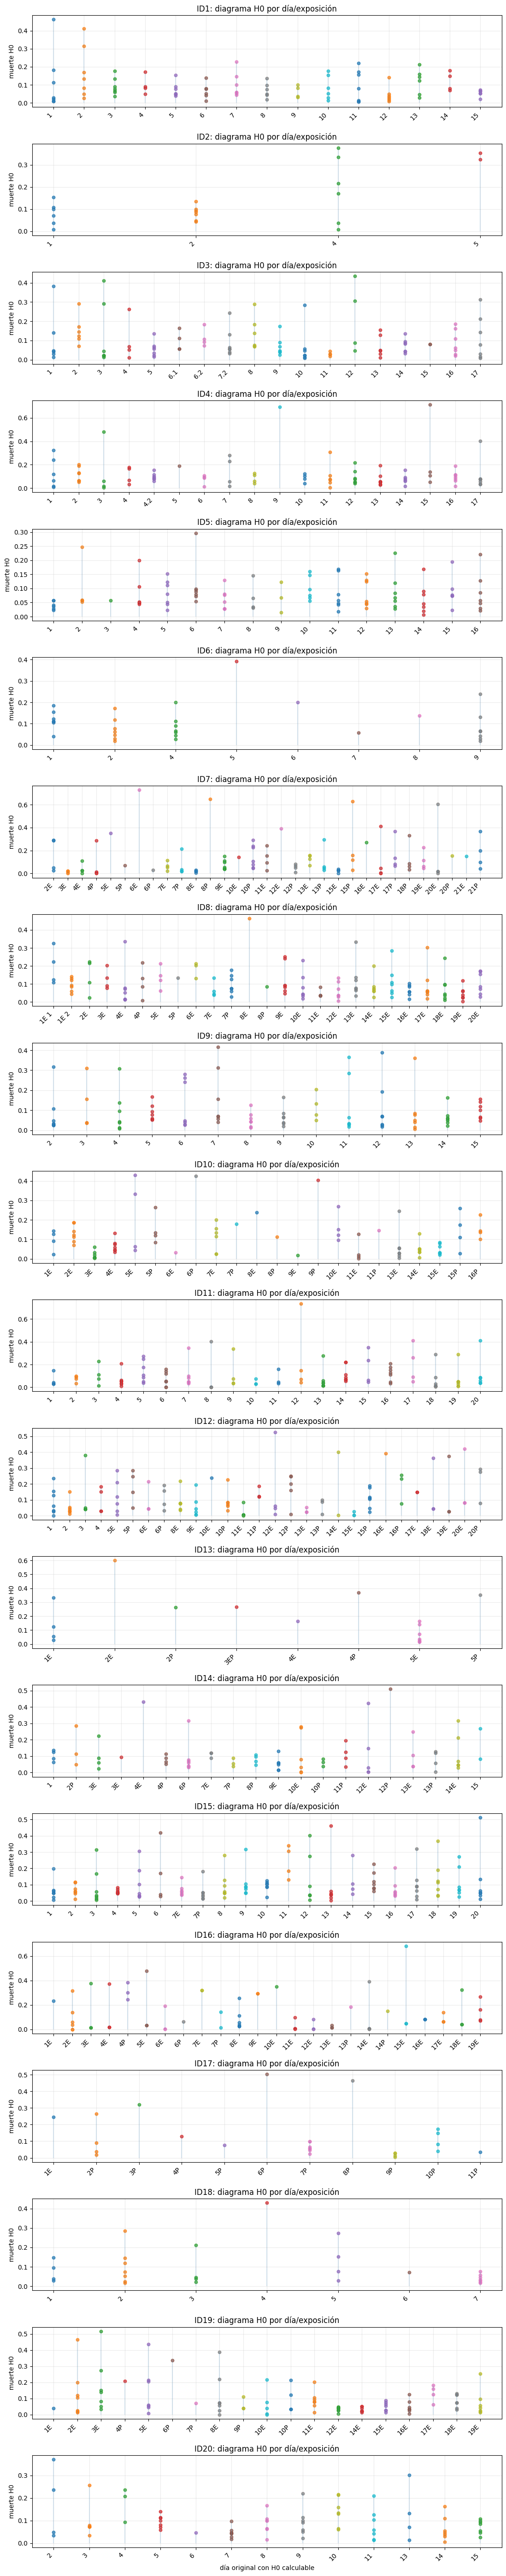

In [4]:
# Visualización compacta: diagramas H0 por día para cada niño.
# Se omiten del eje los días sin suficientes puntos para producir muertes H0.
fig, axes = plt.subplots(len(TARGET_IDS), 1, figsize=(11, max(13, 2.8 * len(TARGET_IDS))), sharex=False)
for ax, kid in zip(axes, TARGET_IDS):
    sub = diag_summary[(diag_summary['id'] == kid) & (diag_summary['n_muertes_H0'] > 0)].copy()
    if sub.empty:
        ax.set_title(f'{kid}: sin días suficientes para H0')
        ax.axis('off')
        continue
    pos_map = {exp: i + 1 for i, exp in enumerate(sub['exposicion_orden'])}
    for _, row in sub.iterrows():
        deaths = diagrams[(row['id'], row['exposicion_orden'])]
        x_pos = pos_map[row['exposicion_orden']]
        x = np.full(len(deaths), x_pos)
        ax.scatter(x, deaths, s=22, alpha=0.75)
        ax.vlines(x_pos, 0, np.max(deaths), alpha=0.16)
    ax.set_title(f'{kid}: diagrama H0 por día/exposición')
    ax.set_ylabel('muerte H0')
    ax.grid(alpha=0.25)
    ax.set_xticks(list(pos_map.values()))
    ax.set_xticklabels(sub['dia'].astype(str), rotation=45, ha='right')
axes[-1].set_xlabel('día original con H0 calculable')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_diagramas_h0_por_nino_dia.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Auditoría H1: ¿hay suficientes puntos para ciclos?

Antes de descartar H1, revisamos si las nubes por niño/día tienen tamaño suficiente para formar ciclos. Un ciclo H1 en un complejo Vietoris-Rips necesita al menos varios puntos alrededor de una región vacía; con 3 o 4 puntos, cualquier ciclo suele llenarse rápidamente por triángulos o ser artefacto del 1-esqueleto.

Por eso esta sección no usa H1 como resultado principal: solo documenta si el análisis sería justificable.

In [5]:
def graph_h1_audit(points, n_eps=18):
    """Auditoría simple de H1 en el 1-esqueleto.

    beta1_graph = E - V + C cuenta ciclos en el grafo.
    triangle_count aproxima cuántos ciclos se rellenarían como 2-símplices en Vietoris-Rips.
    beta1_clique_aprox = max(beta1_graph - triangles, 0) es conservador y solo descriptivo.
    """
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n < 4:
        return {
            'n_puntos': n,
            'eps_con_beta1_graph': 0,
            'eps_con_beta1_clique_aprox': 0,
            'max_beta1_graph': 0,
            'max_beta1_clique_aprox': 0,
            'h1_auditable': False,
            'motivo': 'menos de 4 puntos'
        }
    D = squareform(pdist(points))
    nonzero = D[D > 0]
    if len(nonzero) == 0:
        return {
            'n_puntos': n,
            'eps_con_beta1_graph': 0,
            'eps_con_beta1_clique_aprox': 0,
            'max_beta1_graph': 0,
            'max_beta1_clique_aprox': 0,
            'h1_auditable': False,
            'motivo': 'puntos duplicados o sin distancia'
        }
    eps_grid = np.linspace(nonzero.min(), nonzero.max(), n_eps)
    beta1_graph_values = []
    beta1_clique_values = []
    triangle_values = []
    for eps in eps_grid:
        G = nx.Graph()
        G.add_nodes_from(range(n))
        ii, jj = np.where(np.triu(D <= eps, 1))
        G.add_edges_from(zip(ii.tolist(), jj.tolist()))
        V = n
        E = G.number_of_edges()
        C = nx.number_connected_components(G)
        beta1_graph = E - V + C
        adj = [set(G.neighbors(i)) for i in range(n)]
        triangles = 0
        for i in range(n):
            for j in adj[i]:
                if j > i:
                    triangles += sum(1 for k in adj[i].intersection(adj[j]) if k > j)
        beta1_clique = max(beta1_graph - triangles, 0)
        beta1_graph_values.append(beta1_graph)
        beta1_clique_values.append(beta1_clique)
        triangle_values.append(triangles)
    max_graph = int(np.max(beta1_graph_values))
    max_clique = int(np.max(beta1_clique_values))
    eps_graph = int(np.sum(np.array(beta1_graph_values) > 0))
    eps_clique = int(np.sum(np.array(beta1_clique_values) > 0))
    h1_auditable = (n >= 6) and (eps_clique >= 2) and (max_clique > 0)
    if h1_auditable:
        motivo = 'posible ciclo descriptivo, revisar con cautela'
    elif max_graph > 0 and max_clique == 0:
        motivo = 'ciclos del grafo se rellenan por triángulos VR'
    elif n < 6:
        motivo = 'muy pocos puntos para H1 estable'
    else:
        motivo = 'sin ciclos persistentes aproximados'
    return {
        'n_puntos': n,
        'eps_con_beta1_graph': eps_graph,
        'eps_con_beta1_clique_aprox': eps_clique,
        'max_beta1_graph': max_graph,
        'max_beta1_clique_aprox': max_clique,
        'h1_auditable': h1_auditable,
        'motivo': motivo,
    }

h1_rows = []
for _, row in coverage.iterrows():
    key = (row['id'], row['exposicion_orden'])
    cloud = clouds[key]
    pts = cloud[['valence', 'arousal']].to_numpy(float) if len(cloud) else np.empty((0, 2))
    audit = graph_h1_audit(pts)
    h1_rows.append({
        'id': row['id'],
        'exposicion_orden': row['exposicion_orden'],
        'dia': row['dia'],
        'dia_order': row['dia_order'],
        **audit,
    })

h1_audit = pd.DataFrame(h1_rows)
h1_audit.to_csv(OUTPUT_DIR / '05_auditoria_h1_por_nino_dia.csv', index=False)

h1_summary = h1_audit.groupby('id').agg(
    dias=('dia', 'count'),
    mediana_puntos=('n_puntos', 'median'),
    min_puntos=('n_puntos', 'min'),
    max_puntos=('n_puntos', 'max'),
    dias_con_menos_4_puntos=('n_puntos', lambda s: int((s < 4).sum())),
    dias_con_menos_6_puntos=('n_puntos', lambda s: int((s < 6).sum())),
    dias_con_beta1_graph=('max_beta1_graph', lambda s: int((s > 0).sum())),
    dias_con_beta1_clique_aprox=('max_beta1_clique_aprox', lambda s: int((s > 0).sum())),
    dias_h1_auditable=('h1_auditable', 'sum'),
).reset_index()
h1_summary.to_csv(OUTPUT_DIR / '05_resumen_auditoria_h1_por_nino.csv', index=False)

display(h1_summary)
display(h1_audit.sort_values(['h1_auditable', 'max_beta1_clique_aprox', 'n_puntos'], ascending=[False, False, False]).head(20))

,id,dias,mediana_puntos,min_puntos,max_puntos,dias_con_menos_4_puntos,dias_con_menos_6_puntos,dias_con_beta1_graph,dias_con_beta1_clique_aprox,dias_h1_auditable
0,ID1,15,7.0000,5,8,0,3,15,1,0
1,ID10,24,5.0000,0,8,10,17,14,1,0
2,ID11,20,6.0000,4,8,0,10,20,1,0
3,ID12,29,4.0000,1,8,5,21,24,1,0
4,ID13,8,2.0000,2,8,6,7,2,0,0
5,ID14,23,5.0000,1,8,7,18,16,0,0
6,ID15,21,8.0000,5,8,0,3,21,0,0
7,ID16,27,4.0000,1,7,11,24,16,0,0
8,ID17,13,2.0000,0,8,9,12,4,0,0
9,ID18,7,5.0000,2,8,2,5,5,0,0


,id,exposicion_orden,dia,dia_order,n_puntos,eps_con_beta1_graph,eps_con_beta1_clique_aprox,max_beta1_graph,max_beta1_clique_aprox,h1_auditable,motivo
355,ID9,5,5,5.0000,8,15,1,21,1,False,sin ciclos persistentes aproximados
14,ID1,15,15,15.0000,7,14,1,15,1,False,sin ciclos persistentes aproximados
58,ID11,20,20,20.0000,7,18,1,15,1,False,sin ciclos persistentes aproximados
29,ID10,15,10E,10.0000,5,14,1,6,1,False,muy pocos puntos para H1 estable
204,ID19,18,17E,17.0000,5,8,2,6,1,False,muy pocos puntos para H1 estable
73,ID12,15,11P,11.0000,4,6,4,3,1,False,muy pocos puntos para H1 estable
0,ID1,1,1,1.0000,8,17,0,21,0,False,ciclos del grafo se rellenan por triángulos VR
1,ID1,2,2,2.0000,8,17,0,21,0,False,ciclos del grafo se rellenan por triángulos VR
2,ID1,3,3,3.0000,8,15,0,21,0,False,ciclos del grafo se rellenan por triángulos VR
4,ID1,5,5,5.0000,8,17,0,21,0,False,ciclos del grafo se rellenan por triángulos VR


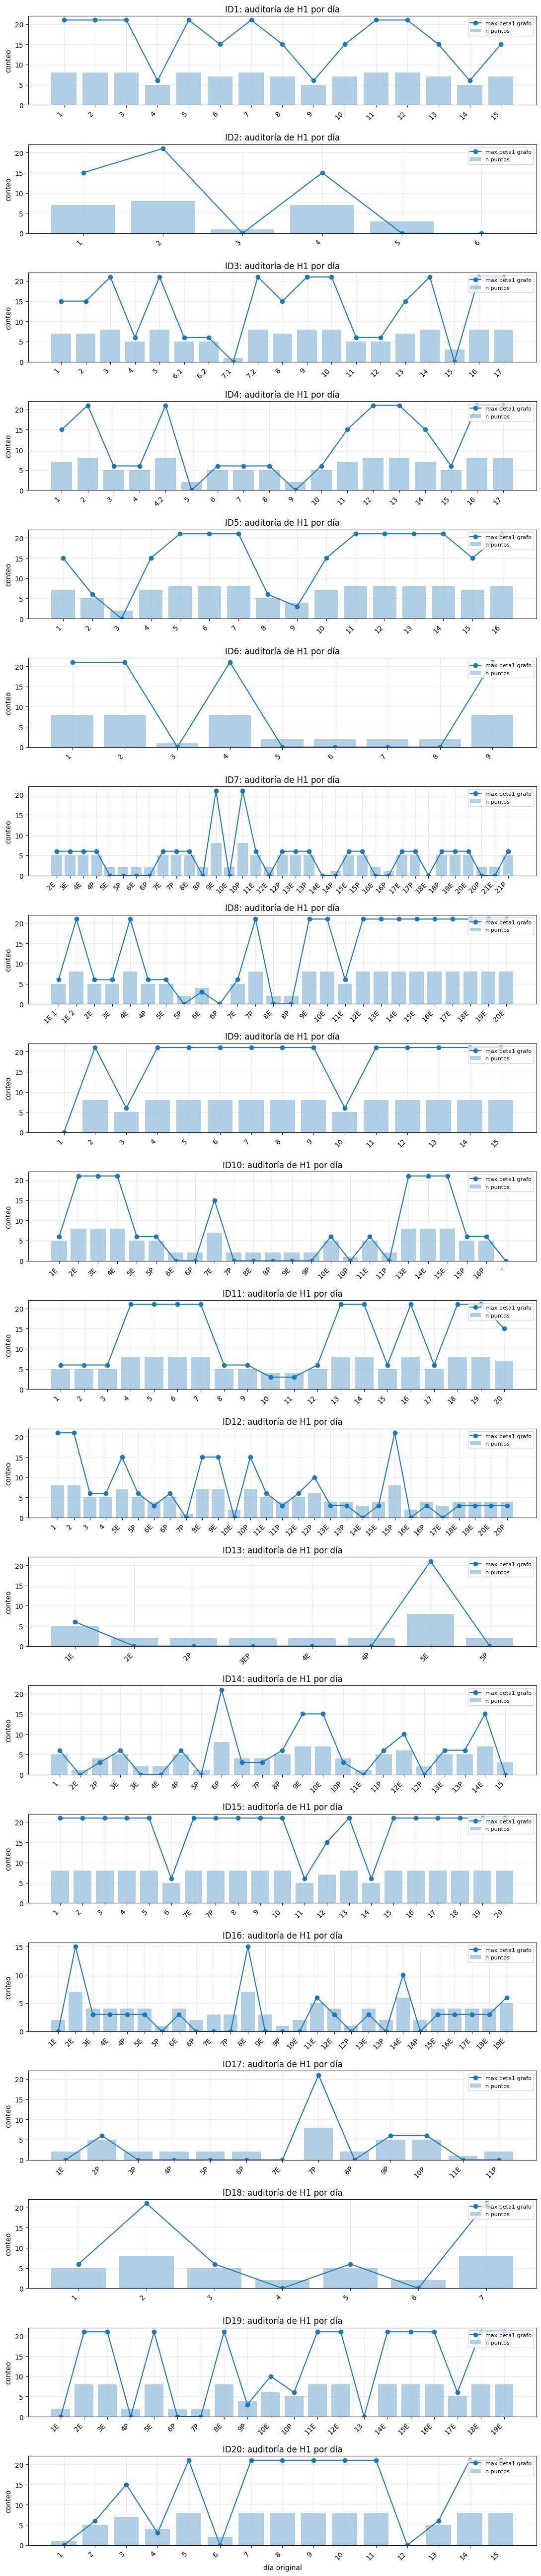

In [6]:
fig, axes = plt.subplots(len(TARGET_IDS), 1, figsize=(11, max(12, 2.6 * len(TARGET_IDS))), sharex=False)
for ax, kid in zip(axes, TARGET_IDS):
    sub = h1_audit[h1_audit['id'] == kid].sort_values('exposicion_orden')
    ax.bar(sub['exposicion_orden'], sub['n_puntos'], alpha=0.35, label='n puntos')
    ax.plot(sub['exposicion_orden'], sub['max_beta1_graph'], marker='o', label='max beta1 grafo')
    ax.set_title(f'{kid}: auditoría de H1 por día')
    ax.set_ylabel('conteo')
    ax.set_xticks(sub['exposicion_orden'])
    ax.set_xticklabels(sub['dia'].astype(str), rotation=45, ha='right')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('día original')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_auditoria_h1_por_nino_dia.png', dpi=160, bbox_inches='tight')
plt.show()

**Conclusión metodológica sobre H1.**

Si `dias_h1_auditable` es bajo o cero, H1 no se usa como evidencia principal. En ese caso, los ciclos detectados en el grafo son demasiado sensibles al número de puntos y al llenado por triángulos de Vietoris-Rips. Para defender el análisis, H0 es más adecuado porque describe conectividad y separación entre etapas con nubes pequeñas.

## 4. Distancia entre diagramas de días consecutivos

Se calculan dos distancias entre diagramas H0 consecutivos:

- **Wasserstein H0 aproximada:** costo acumulado de emparejamiento entre características topológicas.

Se descarta bottleneck como criterio principal porque es muy sensible a un único punto extremo. Para este objetivo interesa más detectar cambios distribuidos en toda la nube afectiva del día.

In [7]:
def h0_cost_matrix(a, b, p=1):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n, m = len(a), len(b)
    N = n + m
    C = np.zeros((N, N), dtype=float)
    # Left: A points + diagonal copies for B. Right: B points + diagonal copies for A.
    for i in range(n):
        for j in range(m):
            C[i, j] = abs(a[i] - b[j])
        for j in range(m, N):
            C[i, j] = a[i] / 2.0
    for i in range(n, N):
        for j in range(m):
            C[i, j] = b[j] / 2.0
        for j in range(m, N):
            C[i, j] = 0.0
    return C


def h0_wasserstein(a, b, p=1):
    C = h0_cost_matrix(a, b, p=p)
    if C.size == 0:
        return 0.0
    rr, cc = linear_sum_assignment(C ** p)
    total = np.sum(C[rr, cc] ** p)
    return float(total ** (1.0 / p))


def h0_bottleneck(a, b):
    C = h0_cost_matrix(a, b)
    if C.size == 0:
        return 0.0
    rr, cc = linear_sum_assignment(C)
    # Para bottleneck exacto pequeño hacemos búsqueda sobre umbrales únicos.
    vals = np.unique(C.ravel())
    lo, hi = 0, len(vals) - 1
    best = vals[-1]
    while lo <= hi:
        mid = (lo + hi) // 2
        threshold = vals[mid]
        G = nx.Graph()
        left = [f'L{i}' for i in range(C.shape[0])]
        right = [f'R{j}' for j in range(C.shape[1])]
        G.add_nodes_from(left, bipartite=0)
        G.add_nodes_from(right, bipartite=1)
        for i in range(C.shape[0]):
            for j in range(C.shape[1]):
                if C[i, j] <= threshold + 1e-12:
                    G.add_edge(left[i], right[j])
        matching = nx.algorithms.bipartite.maximum_matching(G, top_nodes=left)
        if sum(1 for node in left if node in matching) == C.shape[0]:
            best = threshold
            hi = mid - 1
        else:
            lo = mid + 1
    return float(best)

# Prueba mínima de consistencia.
assert abs(h0_bottleneck([1.0], [1.2]) - 0.2) < 1e-9
assert h0_bottleneck([], []) == 0.0

In [8]:
distance_rows = []
for kid in TARGET_IDS:
    sub = diag_summary[diag_summary['id'] == kid].sort_values('exposicion_orden')
    records = sub.to_dict('records')
    for prev, curr in zip(records[:-1], records[1:]):
        a = diagrams[(prev['id'], prev['exposicion_orden'])]
        b = diagrams[(curr['id'], curr['exposicion_orden'])]
        distance_rows.append({
            'id': kid,
            'desde_exposicion': prev['exposicion_orden'],
            'hasta_exposicion': curr['exposicion_orden'],
            'desde_dia': prev['dia'],
            'hasta_dia': curr['dia'],
            'n_puntos_desde': prev['n_puntos'],
            'n_puntos_hasta': curr['n_puntos'],
            'bottleneck_H0': h0_bottleneck(a, b),
            'wasserstein_H0': h0_wasserstein(a, b),
            'delta_centroid': float(np.linalg.norm([
                curr['centroid_valence'] - prev['centroid_valence'],
                curr['centroid_arousal'] - prev['centroid_arousal'],
            ])) if pd.notna(curr['centroid_valence']) and pd.notna(prev['centroid_valence']) else np.nan,
            'delta_diameter': curr['diameter'] - prev['diameter'],
            'delta_h0_max': curr['h0_muerte_max'] - prev['h0_muerte_max'],
        })

distances = pd.DataFrame(distance_rows)
# Umbral robusto por niño usando Wasserstein H0: Q75 + 1.5*IQR;
# si queda demasiado alto con pocos días, también registramos percentil 80.
METRIC_COL = 'wasserstein_H0'
thresholds = []
for kid, sub in distances.groupby('id'):
    q25, q50, q75 = sub[METRIC_COL].quantile([0.25, 0.5, 0.75])
    iqr = q75 - q25
    p80 = sub[METRIC_COL].quantile(0.80)
    thresholds.append({'id': kid, 'metrica_principal': METRIC_COL, 'q25': q25, 'median': q50, 'q75': q75, 'iqr': iqr, 'umbral_iqr': q75 + 1.5 * iqr, 'umbral_p80': p80})
thresholds = pd.DataFrame(thresholds)
distances = distances.merge(thresholds[['id','median','umbral_iqr','umbral_p80']], on='id', how='left')
distances['transicion_orden'] = distances.groupby('id').cumcount() + 1
distances['cambio_alto_relativo'] = (distances[METRIC_COL] >= distances['umbral_p80']) | (distances[METRIC_COL] >= distances['umbral_iqr'])

distances.to_csv(OUTPUT_DIR / '05_distancias_h0_consecutivas_por_nino.csv', index=False)
thresholds.to_csv(OUTPUT_DIR / '05_umbrales_distancia_por_nino.csv', index=False)
display(thresholds.round(4))
display(distances.sort_values(['id','bottleneck_H0'], ascending=[True, False]).head(20).round(4))

,id,metrica_principal,q25,median,q75,iqr,umbral_iqr,umbral_p80
0,ID1,wasserstein_H0,0.1459,0.1861,0.2819,0.1359,0.4857,0.2929
1,ID10,wasserstein_H0,0.1383,0.2282,0.3186,0.1803,0.5890,0.3232
2,ID11,wasserstein_H0,0.1571,0.2776,0.3498,0.1927,0.6388,0.3798
3,ID12,wasserstein_H0,0.1698,0.2475,0.3093,0.1395,0.5186,0.3276
4,ID13,wasserstein_H0,0.1536,0.3354,0.3501,0.1965,0.6448,0.3554
5,ID14,wasserstein_H0,0.1592,0.2228,0.3188,0.1596,0.5582,0.3325
6,ID15,wasserstein_H0,0.2237,0.2705,0.3427,0.1191,0.5214,0.3687
7,ID16,wasserstein_H0,0.1266,0.2190,0.2895,0.1630,0.5340,0.3044
8,ID17,wasserstein_H0,0.1187,0.2218,0.2556,0.1368,0.4608,0.2655
9,ID18,wasserstein_H0,0.2325,0.2481,0.2689,0.0365,0.3237,0.2713


,id,desde_exposicion,hasta_exposicion,desde_dia,hasta_dia,n_puntos_desde,n_puntos_hasta,bottleneck_H0,wasserstein_H0,delta_centroid,delta_diameter,delta_h0_max,median,umbral_iqr,umbral_p80,transicion_orden,cambio_alto_relativo
1,ID1,2,3,2,3,8,8,0.2066,0.4749,0.1695,-0.2734,-0.2363,0.1861,0.4857,0.2929,2,True
0,ID1,1,2,1,2,8,8,0.1337,0.3199,0.0276,-0.0960,-0.0501,0.1861,0.4857,0.2929,1,True
6,ID1,7,8,7,8,8,7,0.0932,0.1816,0.2259,-0.1318,-0.0932,0.1861,0.4857,0.2929,7,False
13,ID1,14,15,14,15,5,7,0.0903,0.2490,0.0643,-0.1565,-0.1096,0.1861,0.4857,0.2929,14,False
5,ID1,6,7,6,7,7,8,0.0901,0.1991,0.2011,0.1867,0.0901,0.1861,0.4857,0.2929,6,False
10,ID1,11,12,11,12,8,8,0.0859,0.2931,0.3046,-0.1441,-0.0791,0.1861,0.4857,0.2929,11,True
11,ID1,12,13,12,13,8,7,0.0795,0.2928,0.1516,0.2821,0.0709,0.1861,0.4857,0.2929,12,False
8,ID1,9,10,9,10,5,7,0.0777,0.1702,0.0347,0.1753,0.0777,0.1861,0.4857,0.2929,9,False
9,ID1,10,11,10,11,7,8,0.0725,0.1682,0.1886,0.0786,0.0432,0.1861,0.4857,0.2929,10,False
12,ID1,13,14,13,14,7,5,0.0619,0.1907,0.1316,-0.1758,-0.0313,0.1861,0.4857,0.2929,13,False


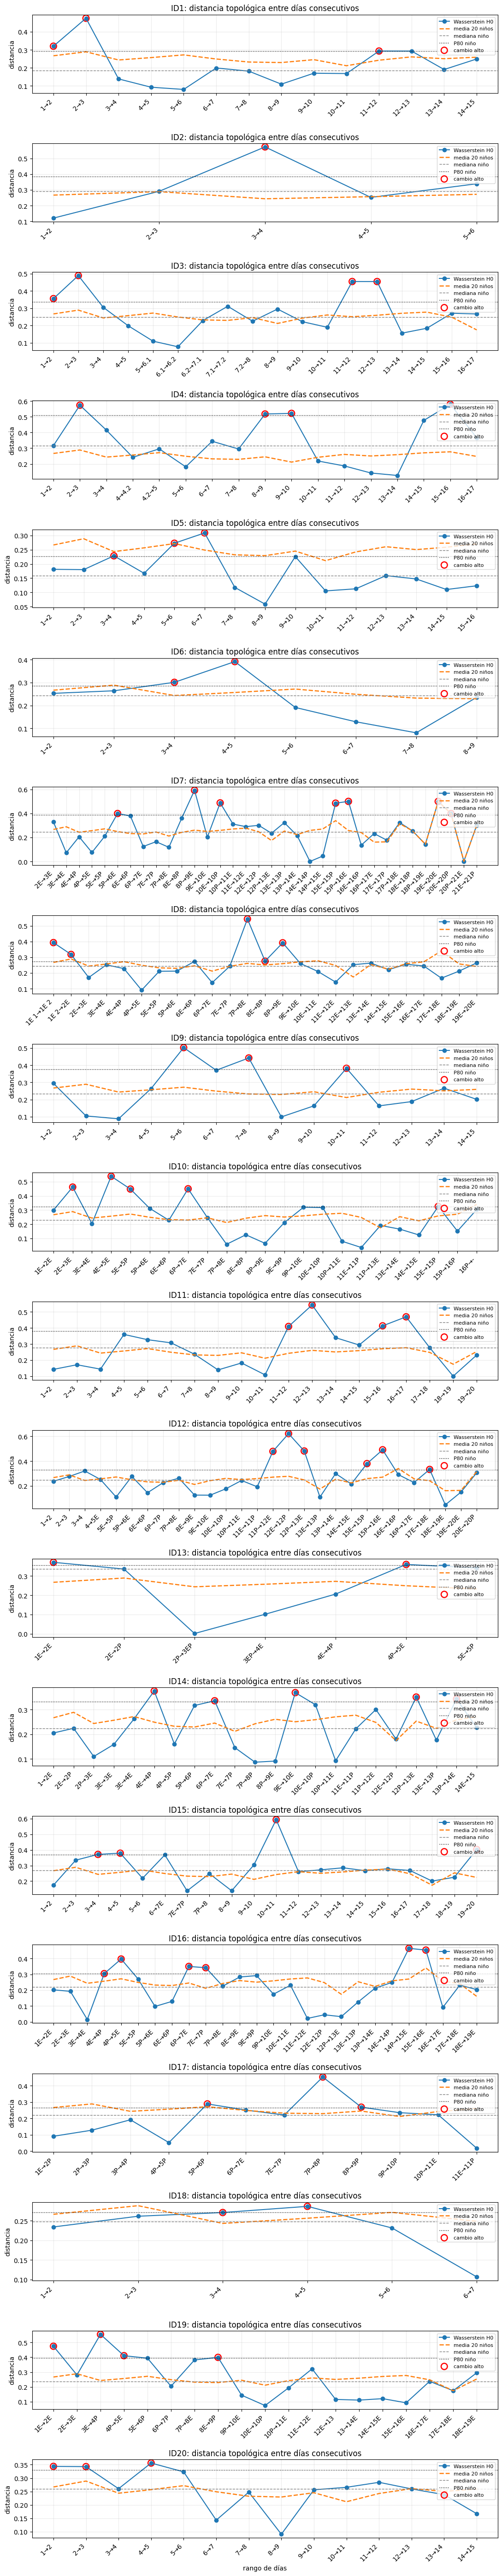

In [9]:
media_global_por_transicion = distances.groupby('transicion_orden')['wasserstein_H0'].mean()

fig, axes = plt.subplots(len(TARGET_IDS), 1, figsize=(11, max(13, 2.8 * len(TARGET_IDS))), sharex=False)
for ax, kid in zip(axes, TARGET_IDS):
    sub = distances[distances['id'] == kid].sort_values('hasta_exposicion')
    labels = [f"{a}→{b}" for a, b in zip(sub['desde_dia'], sub['hasta_dia'])]
    x = np.arange(len(sub))
    ax.plot(x, sub['wasserstein_H0'], marker='o', label='Wasserstein H0')
    media_alineada = sub['transicion_orden'].map(media_global_por_transicion).to_numpy()
    ax.plot(x, media_alineada, color='tab:orange', linestyle='--', linewidth=1.8, label='media 20 niños')
    ax.axhline(sub['median'].iloc[0], color='gray', linestyle='--', linewidth=1, label='mediana niño')
    ax.axhline(sub['umbral_p80'].iloc[0], color='black', linestyle=':', linewidth=1, label='P80 niño')
    high = sub['cambio_alto_relativo'].to_numpy()
    ax.scatter(np.where(high)[0], sub.loc[high, 'wasserstein_H0'], s=95, facecolors='none', edgecolors='red', linewidths=1.8, label='cambio alto')
    ax.set_title(f'{kid}: distancia topológica entre días consecutivos')
    ax.set_ylabel('distancia')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('rango de días')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_series_distancias_topologicas_por_nino.png', dpi=160, bbox_inches='tight')
plt.show()

## Media de distancia Wasserstein de los 20 niños

Para observar el comportamiento agregado, se promedia la distancia Wasserstein H0 por número de transición dentro de cada niño. Por ejemplo, la transición 1 representa el cambio entre la primera y segunda exposición disponible de cada niño.

,transicion_orden,n_ninos,n_pares,wasserstein_media,wasserstein_mediana,wasserstein_sd,cambios_altos,wasserstein_sem
0,1,20,20,0.2668,0.2736,0.0996,6,0.0223
1,2,20,20,0.2888,0.2782,0.1341,6,0.0300
2,3,20,20,0.2435,0.2171,0.1540,6,0.0344
3,4,20,20,0.2567,0.2519,0.1272,7,0.0284
4,5,20,20,0.2717,0.2676,0.1115,5,0.0249
5,6,19,19,0.2489,0.2704,0.1059,4,0.0243
6,7,18,18,0.2322,0.2247,0.1062,1,0.0250
7,8,17,17,0.2293,0.2262,0.1266,3,0.0307
8,9,16,16,0.2452,0.2364,0.0968,4,0.0242
9,10,16,16,0.2116,0.1569,0.1301,3,0.0325


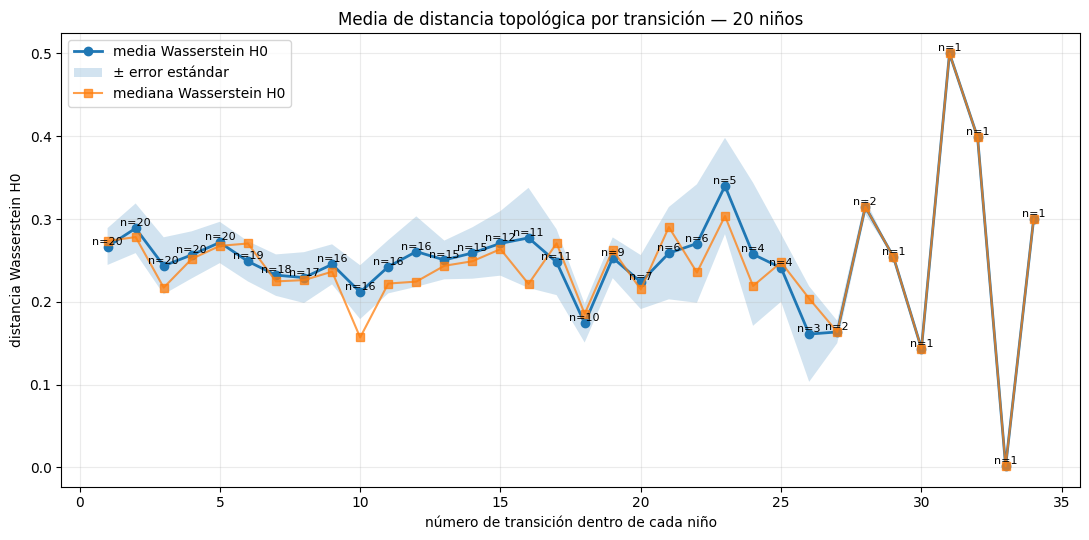

In [10]:
mean_wasserstein = distances.groupby('transicion_orden').agg(
    n_ninos=('id', 'nunique'),
    n_pares=('wasserstein_H0', 'count'),
    wasserstein_media=('wasserstein_H0', 'mean'),
    wasserstein_mediana=('wasserstein_H0', 'median'),
    wasserstein_sd=('wasserstein_H0', 'std'),
    cambios_altos=('cambio_alto_relativo', 'sum'),
).reset_index()
mean_wasserstein['wasserstein_sem'] = mean_wasserstein['wasserstein_sd'] / np.sqrt(mean_wasserstein['n_pares'])
mean_wasserstein.to_csv(OUTPUT_DIR / '05_media_wasserstein_20_ninos_por_transicion.csv', index=False)
display(mean_wasserstein.round(4))

fig, ax = plt.subplots(figsize=(11, 5.5))
x = mean_wasserstein['transicion_orden'].to_numpy()
y = mean_wasserstein['wasserstein_media'].to_numpy()
sem = mean_wasserstein['wasserstein_sem'].fillna(0).to_numpy()
ax.plot(x, y, marker='o', linewidth=2, label='media Wasserstein H0')
ax.fill_between(x, y - sem, y + sem, alpha=0.2, label='± error estándar')
ax.plot(x, mean_wasserstein['wasserstein_mediana'], marker='s', linewidth=1.5, alpha=0.75, label='mediana Wasserstein H0')
for _, row in mean_wasserstein.iterrows():
    ax.text(row['transicion_orden'], row['wasserstein_media'], f"n={int(row['n_ninos'])}", fontsize=8, ha='center', va='bottom')
ax.set_xlabel('número de transición dentro de cada niño')
ax.set_ylabel('distancia Wasserstein H0')
ax.set_title('Media de distancia topológica por transición — 20 niños')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / '05_media_wasserstein_20_ninos_por_transicion.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Bootstrap topológico

Para cada par de días consecutivos se re-muestrean con reemplazo los puntos de etapa dentro de cada día. En cada re-muestreo se recalcula el diagrama H0 y su distancia.

Esto permite estimar si la distancia observada es estable o si depende demasiado de una etapa específica. Se reporta:

- media bootstrap
- intervalo 95%
- ancho relativo del intervalo
- marca de cambio robusto cuando la distancia es alta y el intervalo bootstrap queda por encima de la mediana del niño

In [11]:
def bootstrap_pair_distance(cloud_a, cloud_b, n_boot=N_BOOT, rng=RNG):
    pts_a = cloud_a[['valence','arousal']].to_numpy(float)
    pts_b = cloud_b[['valence','arousal']].to_numpy(float)
    if len(pts_a) < 2 or len(pts_b) < 2:
        return np.full(n_boot, np.nan)
    out = []
    for _ in range(n_boot):
        ia = rng.integers(0, len(pts_a), size=len(pts_a))
        ib = rng.integers(0, len(pts_b), size=len(pts_b))
        da = h0_deaths(pts_a[ia])
        db = h0_deaths(pts_b[ib])
        out.append(h0_wasserstein(da, db))
    return np.array(out, dtype=float)

boot_rows = []
boot_examples = {}
for _, row in distances.iterrows():
    key_a = (row['id'], int(row['desde_exposicion']))
    key_b = (row['id'], int(row['hasta_exposicion']))
    samples = bootstrap_pair_distance(clouds[key_a], clouds[key_b])
    valid = samples[np.isfinite(samples)]
    if len(valid) == 0:
        stats = {'boot_mean': np.nan, 'boot_ci_low': np.nan, 'boot_ci_high': np.nan, 'boot_sd': np.nan, 'boot_rel_width': np.nan}
    else:
        ci_low, ci_high = np.percentile(valid, [2.5, 97.5])
        stats = {
            'boot_mean': valid.mean(),
            'boot_ci_low': ci_low,
            'boot_ci_high': ci_high,
            'boot_sd': valid.std(ddof=1),
            'boot_rel_width': (ci_high - ci_low) / max(row[METRIC_COL], 1e-9),
        }
    boot_rows.append({**row.to_dict(), **stats})
    if row['cambio_alto_relativo']:
        boot_examples[(row['id'], row['desde_dia'], row['hasta_dia'])] = valid

boot = pd.DataFrame(boot_rows)
boot['bootstrap_estable'] = boot['boot_rel_width'] <= 2.5
boot['cambio_robusto'] = boot['cambio_alto_relativo'] & (boot['boot_ci_low'] > boot['median']) & boot['bootstrap_estable']
boot.to_csv(OUTPUT_DIR / '05_bootstrap_topologico_distancias.csv', index=False)
display(boot.sort_values(['cambio_robusto', METRIC_COL], ascending=[False, False]).head(25).round(4))

,id,desde_exposicion,hasta_exposicion,desde_dia,hasta_dia,n_puntos_desde,n_puntos_hasta,bottleneck_H0,wasserstein_H0,delta_centroid,delta_diameter,delta_h0_max,median,umbral_iqr,umbral_p80,transicion_orden,cambio_alto_relativo,boot_mean,boot_ci_low,boot_ci_high,boot_sd,boot_rel_width,bootstrap_estable,cambio_robusto
207,ID12,16,17,12E,12P,5,6,0.2633,0.6215,0.1187,0.2052,-0.2754,0.2475,0.5186,0.3276,16,True,0.6951,0.3244,1.3733,0.2563,1.6875,True,True
259,ID15,11,12,10,11,8,5,0.1701,0.5935,0.1047,0.2672,0.2166,0.2705,0.5214,0.3687,11,True,0.6975,0.2900,1.3598,0.2857,1.8025,True,True
315,ID19,3,4,3E,4P,8,2,0.2589,0.5549,0.3632,-0.7177,-0.3092,0.2376,0.7713,0.3961,3,True,0.7102,0.3997,1.2624,0.2314,1.5546,True,True
122,ID8,12,13,7P,8E,8,2,0.2321,0.5432,0.1404,0.0976,0.2882,0.2443,0.3439,0.2735,12,True,0.4753,0.2630,0.7132,0.1257,0.8286,True,True
20,ID3,2,3,2,3,7,8,0.1189,0.4890,0.2018,0.2134,0.1182,0.2473,0.4865,0.3378,2,True,0.5692,0.3335,0.9098,0.1422,1.1785,True,True
90,ID7,14,15,10E,10P,2,8,0.1447,0.4877,0.4897,0.4389,0.1466,0.2447,0.6573,0.3867,14,True,0.5785,0.3422,1.0113,0.1683,1.3719,True,True
208,ID12,17,18,12P,13E,6,4,0.1256,0.4813,0.1229,-0.7504,-0.1977,0.2475,0.5186,0.3276,17,True,0.6325,0.3406,1.2093,0.2194,1.8048,True,True
151,ID10,2,3,2E,3E,8,8,0.0936,0.4624,0.5204,-0.6101,-0.1273,0.2282,0.5890,0.3232,2,True,0.6037,0.3769,0.9853,0.1735,1.3159,True,True
157,ID10,8,9,6P,7E,2,7,0.2125,0.4502,0.5612,0.0081,-0.2245,0.2282,0.5890,0.3232,8,True,0.4761,0.2342,0.7798,0.1551,1.2119,True,True
142,ID9,7,8,7,8,8,8,0.2086,0.4419,0.1488,-0.6371,-0.2903,0.2324,0.6335,0.3749,7,True,0.6101,0.2592,1.1852,0.2541,2.0957,True,True


## 6. Rastreo de anomalías: ¿de dónde viene el cambio?

Para los rangos marcados como cambio alto o robusto se revisan:

- qué etapas cambiaron más entre días consecutivos,
- cambio de centroide,
- cambio de diámetro,
- conducta (`consume`, `rechaza`, etc.),
- comentarios originales.

In [12]:
def trace_pair(row):
    kid = row['id']
    a_order = int(row['desde_exposicion'])
    b_order = int(row['hasta_exposicion'])
    cloud_a = clouds[(kid, a_order)]
    cloud_b = clouds[(kid, b_order)]
    merged = cloud_a.merge(cloud_b, on='stage', how='inner', suffixes=('_desde','_hasta'))
    stage_changes = []
    for _, s in merged.iterrows():
        dv = s['valence_hasta'] - s['valence_desde']
        da = s['arousal_hasta'] - s['arousal_desde']
        stage_changes.append({
            'stage': s['stage'],
            'delta_valence': dv,
            'delta_arousal': da,
            'distancia_etapa': float(np.linalg.norm([dv, da])),
        })
    stage_changes = pd.DataFrame(stage_changes).sort_values('distancia_etapa', ascending=False)
    raw_a = df[(df['id'] == kid) & (df['exposicion_orden'] == a_order)].iloc[0]
    raw_b = df[(df['id'] == kid) & (df['exposicion_orden'] == b_order)].iloc[0]
    top = '; '.join(
        f"{r.stage}: d={r.distancia_etapa:0.3f} (Δv={r.delta_valence:0.3f}, Δa={r.delta_arousal:0.3f})"
        for r in stage_changes.head(3).itertuples()
    ) if len(stage_changes) else 'sin etapas comunes suficientes'
    behavior_delta = []
    for col in BEHAVIOR_COLS:
        va, vb = raw_a.get(col, np.nan), raw_b.get(col, np.nan)
        if pd.notna(va) or pd.notna(vb):
            behavior_delta.append(f"{col}: {va}→{vb}")
    return {
        'id': kid,
        'rango_dias': f"{row['desde_dia']}→{row['hasta_dia']}",
        'wasserstein_H0': row['wasserstein_H0'],
        'boot_ci': f"[{row['boot_ci_low']:0.3f}, {row['boot_ci_high']:0.3f}]",
        'cambio_robusto': row['cambio_robusto'],
        'delta_centroid': row['delta_centroid'],
        'delta_diameter': row['delta_diameter'],
        'etapas_que_mas_cambian': top,
        'conducta': '; '.join(behavior_delta),
        'comentario_desde': raw_a.get('comentarios', ''),
        'comentario_hasta': raw_b.get('comentarios', ''),
    }

candidates = boot[boot['cambio_alto_relativo'] | boot['cambio_robusto']].copy()
trace = pd.DataFrame([trace_pair(row) for _, row in candidates.iterrows()])
trace = trace.sort_values(['cambio_robusto','wasserstein_H0'], ascending=[False, False]) if len(trace) else trace
trace.to_csv(OUTPUT_DIR / '05_rastreo_anomalias_topologicas.csv', index=False)
display(trace)

,id,rango_dias,wasserstein_H0,boot_ci,cambio_robusto,delta_centroid,delta_diameter,etapas_que_mas_cambian,conducta,comentario_desde,comentario_hasta
42,ID12,12E→12P,0.6215,"[0.324, 1.373]",True,0.1187,0.2052,"p1_after: d=0.407 (Δv=0.188, Δa=0.360); final:...",rechaza: 1.0→0.0; llora: 0.0→0.0; toca: 1.0→1....,solo lo toma,prueba la papilla mientras juega con el colifl...
56,ID15,10→11,0.5935,"[0.290, 1.360]",True,0.1047,0.2672,"inicio: d=0.651 (Δv=0.446, Δa=0.474); p1_befor...",rechaza: 0.0→0.0; llora: 0.0→0.0; toca: 1.0→1....,A y V final anotados de segundo 20.16,A y V inicial tomado del segundo 5.40. Consume...
70,ID19,3E→4P,0.5549,"[0.400, 1.262]",True,0.3632,-0.7177,"inicio: d=0.889 (Δv=0.321, Δa=0.829); final: d...",rechaza: 0.0→1.0; llora: 0.0→1.0; toca: 1.0→0....,NaN,NaN
26,ID8,7P→8E,0.5432,"[0.263, 0.713]",True,0.1404,0.0976,"final: d=0.149 (Δv=-0.024, Δa=0.147); inicio: ...",rechaza: 0.0→1.0; llora: 0.0→0.0; toca: 0.0→0....,Se le entrega la cuchara para que pruebe ella....,Empuja el plato sin tocar el alimento.
5,ID3,2→3,0.4890,"[0.333, 0.910]",True,0.2018,0.2134,"inicio: d=0.804 (Δv=-0.342, Δa=-0.727); p2_dur...",rechaza: 0.0→0.0; llora: 0.0→0.0; toca: 0.0→0....,NaN,Esquiva la cuchara ¿rechazo?
...,...,...,...,...,...,...,...,...,...,...,...
64,ID17,5P→6P,0.2889,"[0.000, 0.289]",False,0.1264,0.4264,"final: d=0.370 (Δv=-0.034, Δa=0.369); inicio: ...",rechaza: 1.0→1.0; llora: 0.0→0.0; toca: 0.0→0....,"No prueba la papilla, sin embargo en el video ...",NaN
68,ID18,4→5,0.2871,"[0.073, 0.715]",False,0.2040,0.0945,"inicio: d=0.613 (Δv=-0.286, Δa=-0.542); final:...",rechaza: 1.0→1.0; llora: 0.0→0.0; toca: 0.0→0....,No prueba ni lo toca con los labios,"Come lo de los labios, no por cuenta propia"
27,ID8,8E→8P,0.2749,"[0.000, 0.275]",False,0.0243,-0.3787,"inicio: d=0.266 (Δv=0.023, Δa=0.265); final: d...",rechaza: 1.0→1.0; llora: 0.0→0.0; toca: 0.0→0....,Empuja el plato sin tocar el alimento.,Rechaza cucharada girando al cara. Valores ini...
67,ID18,3→4,0.2713,"[0.062, 0.513]",False,0.2168,0.1641,"inicio: d=0.427 (Δv=0.175, Δa=0.390); final: d...",rechaza: 1.0→1.0; llora: 0.0→0.0; toca: 0.0→0....,Solo lo toca con los labios,No prueba ni lo toca con los labios


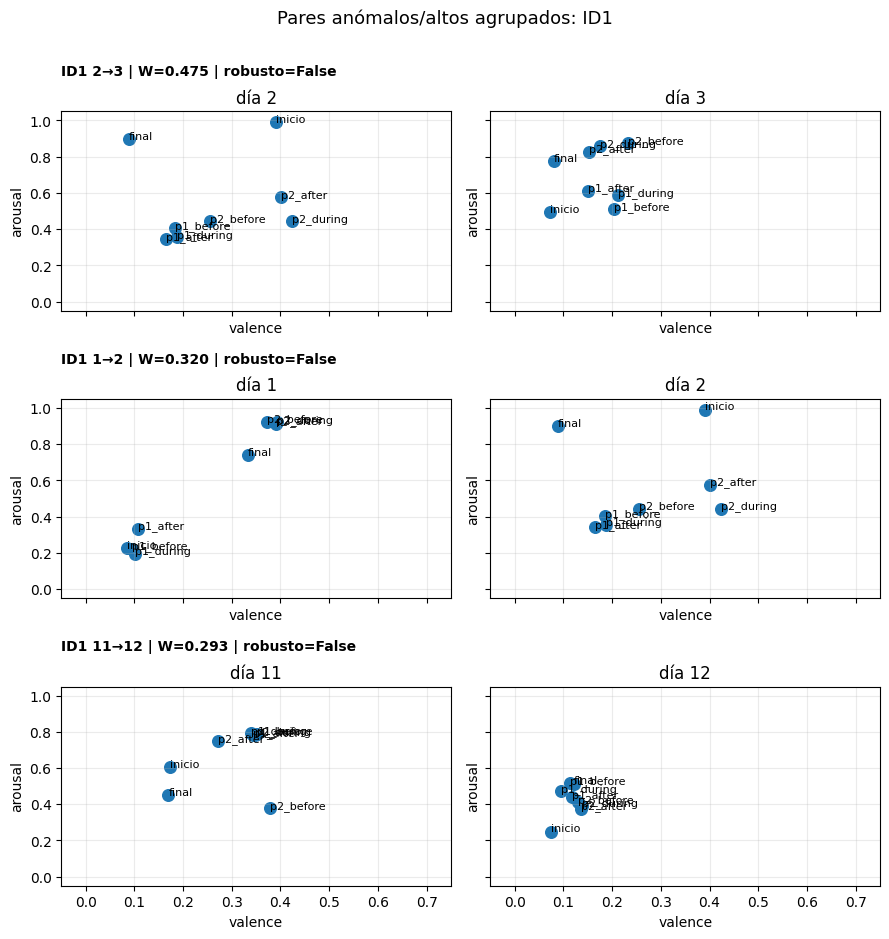

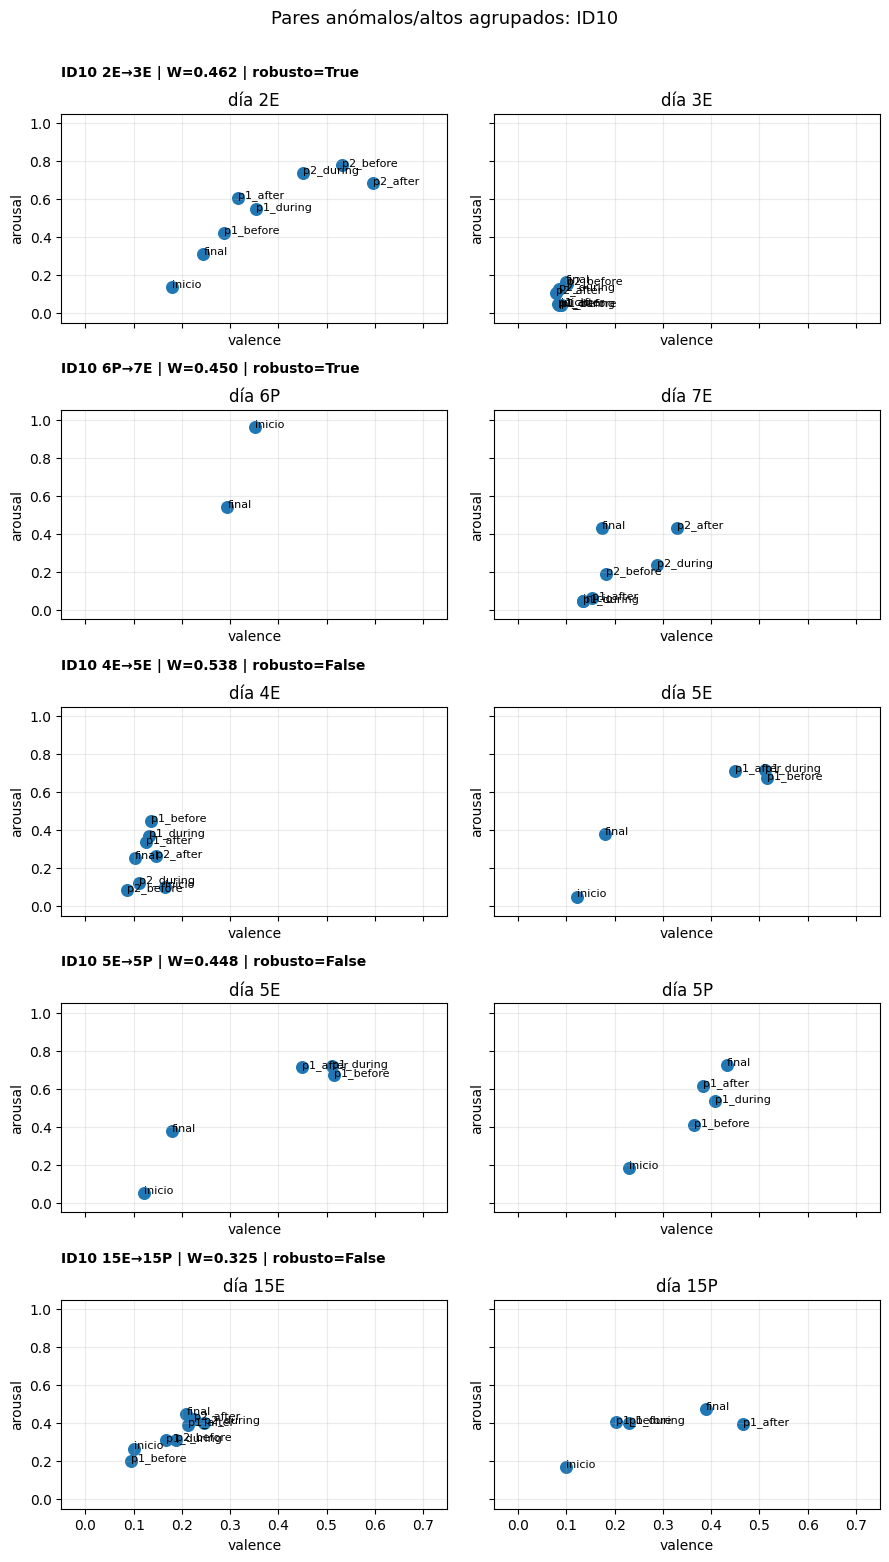

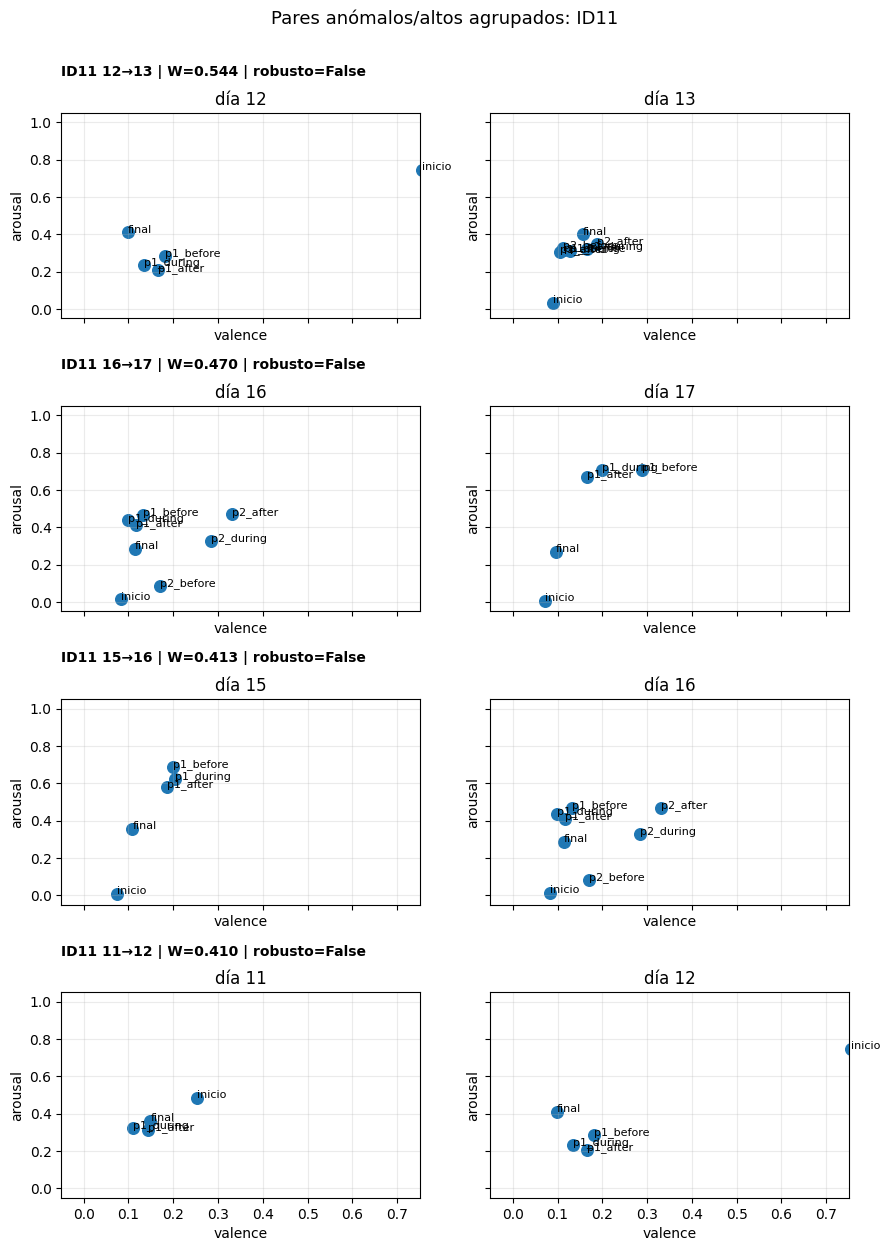

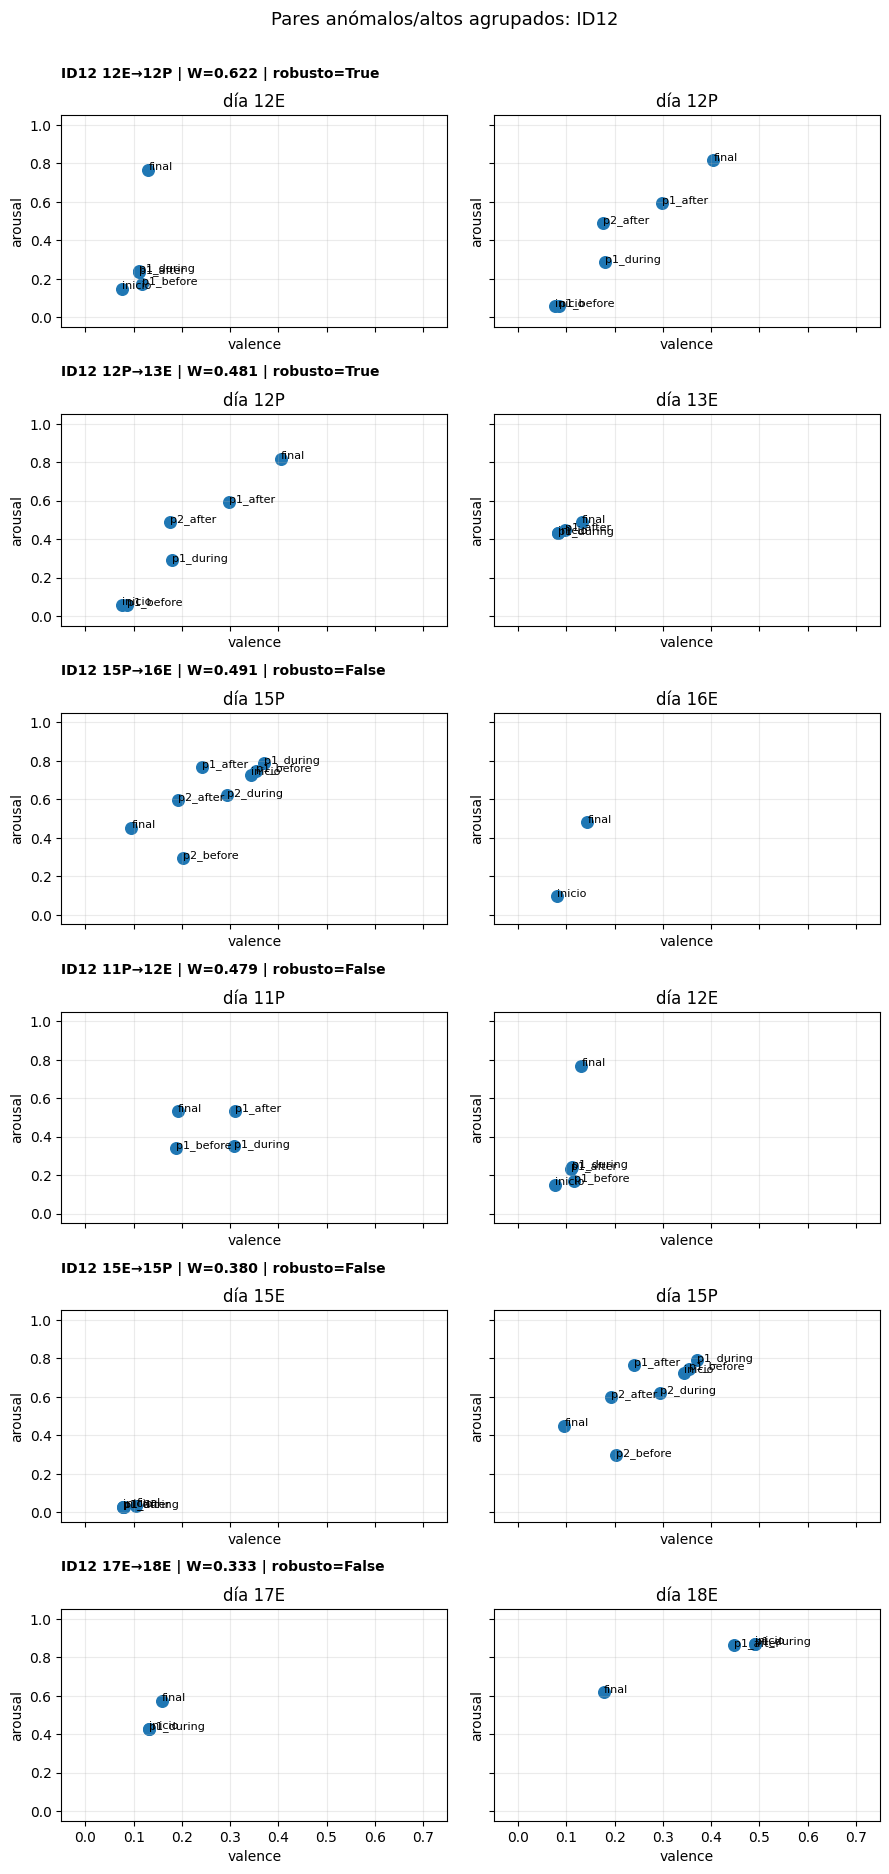

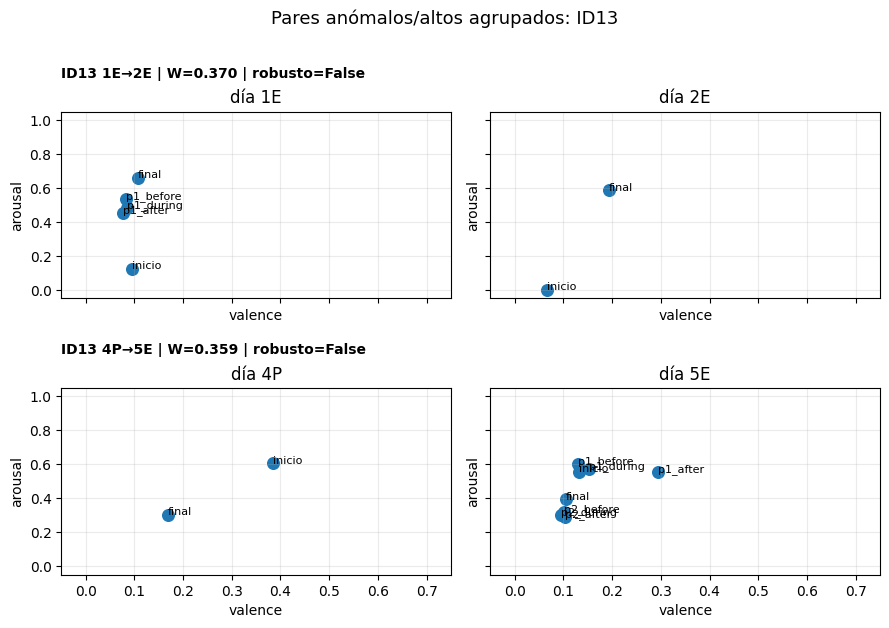

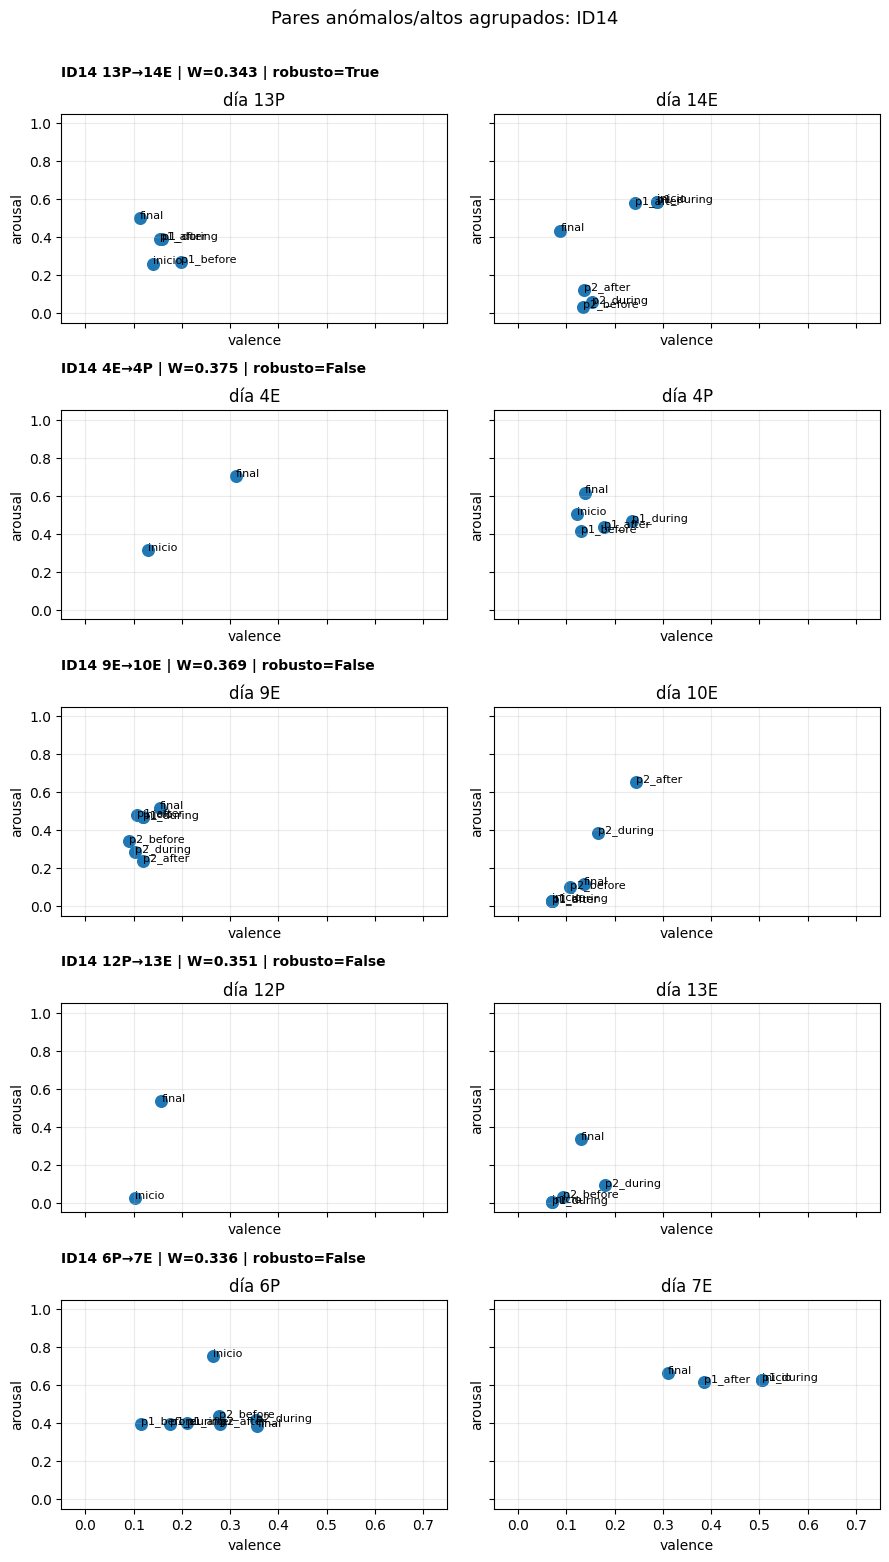

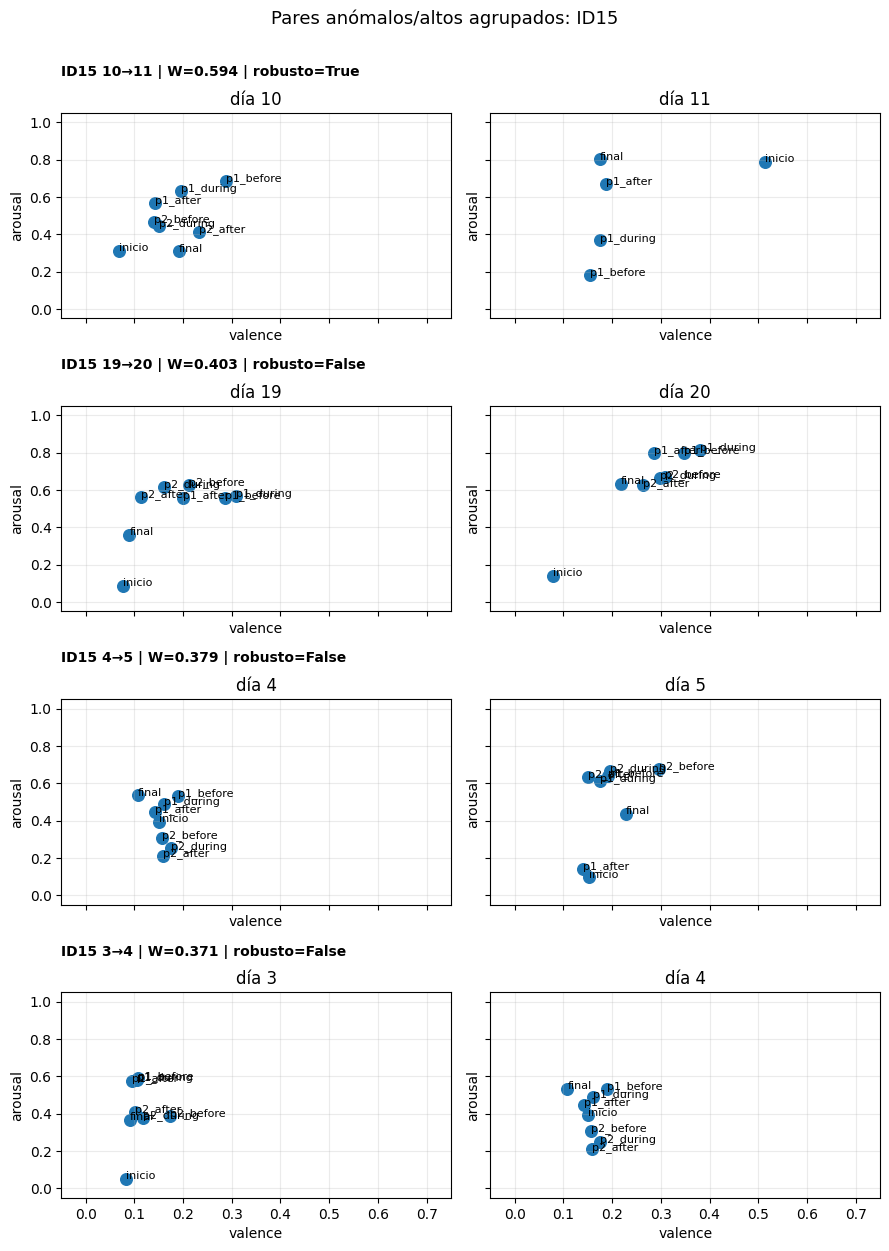

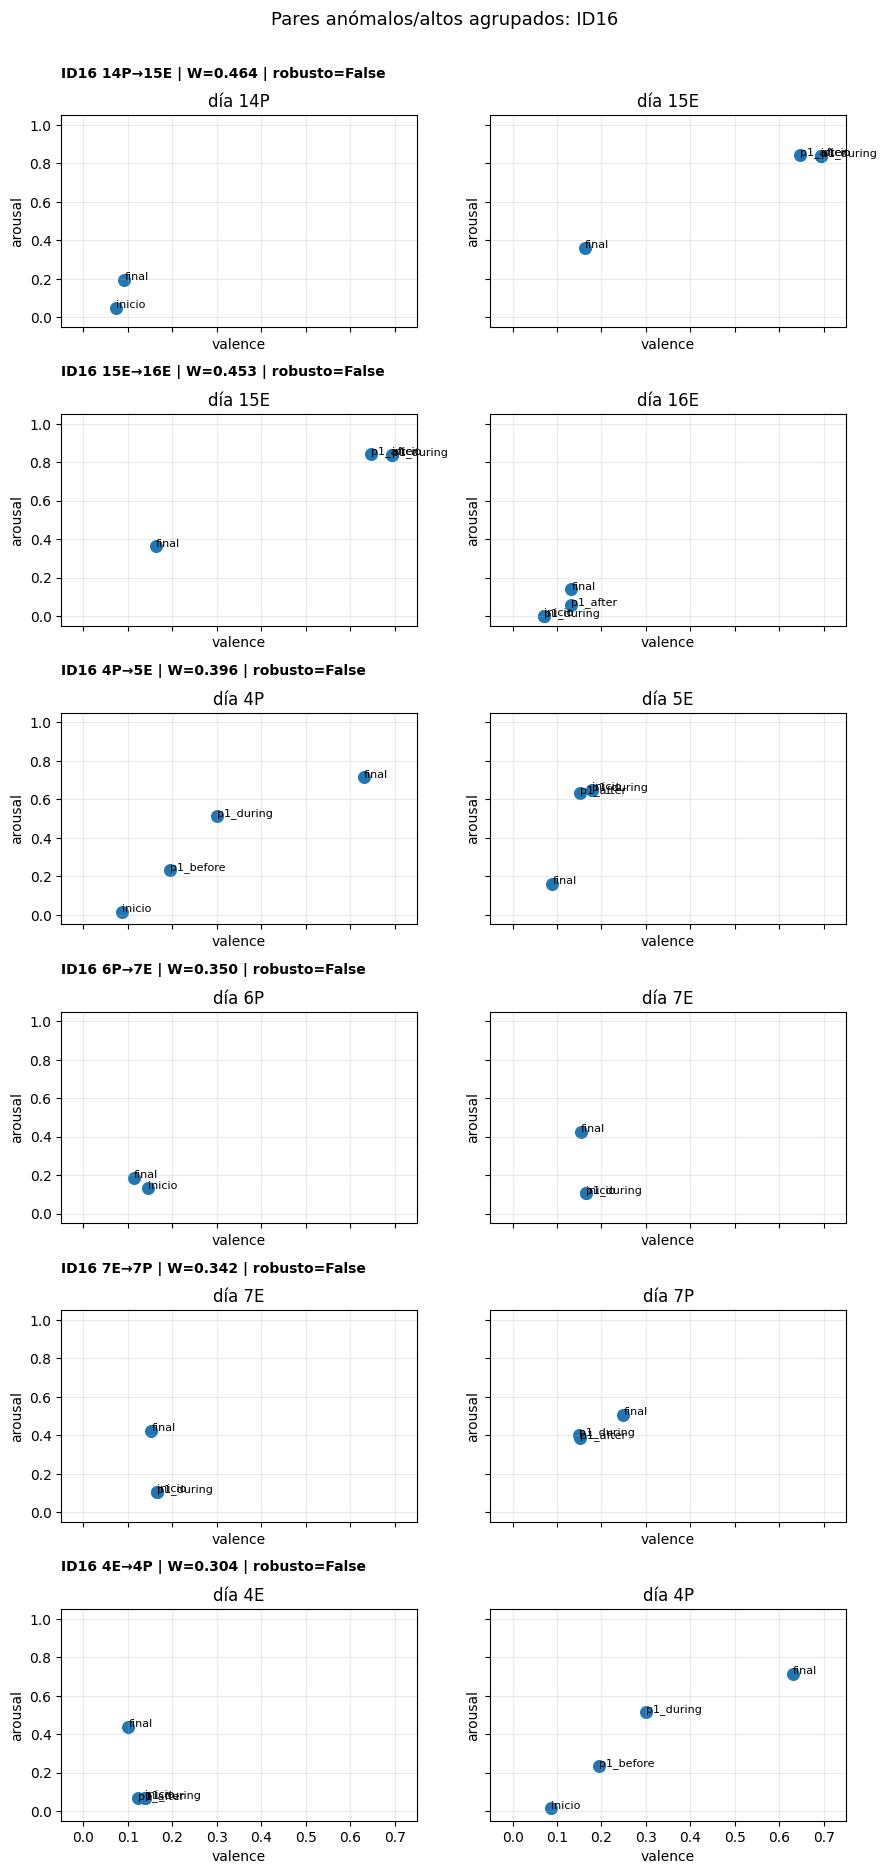

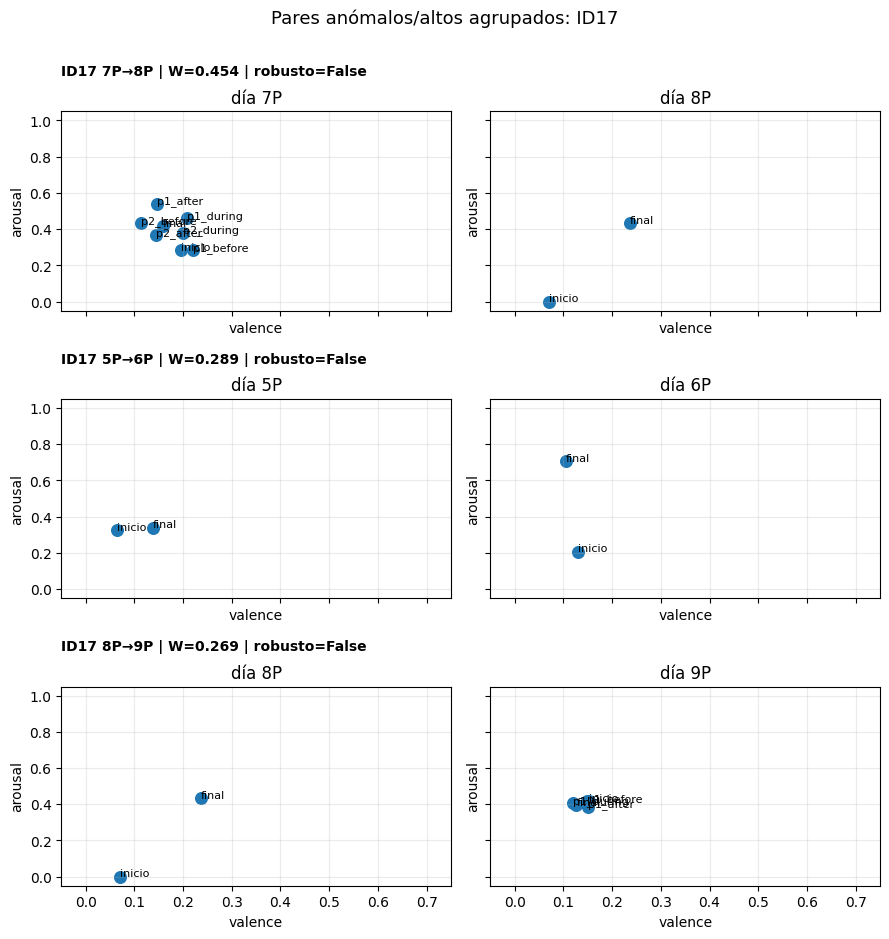

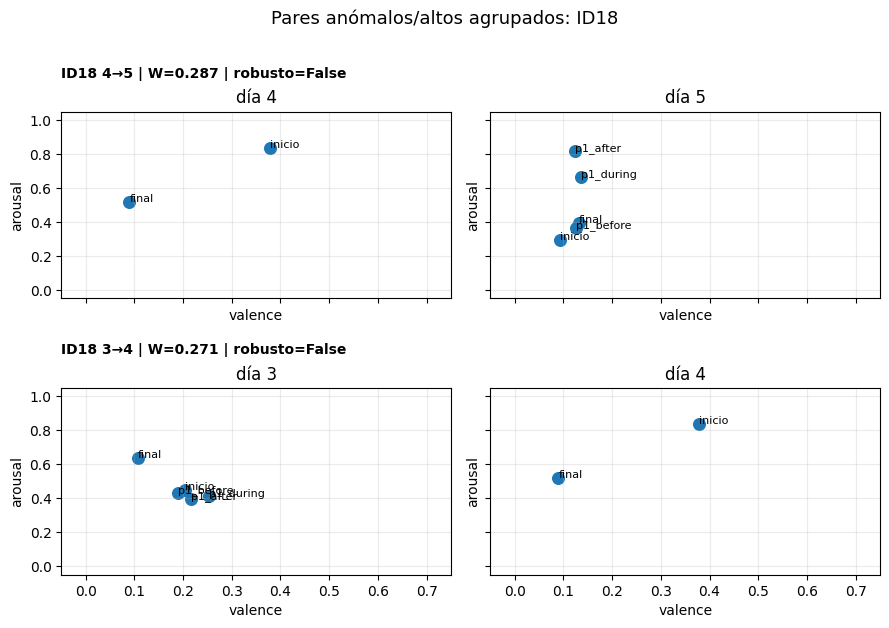

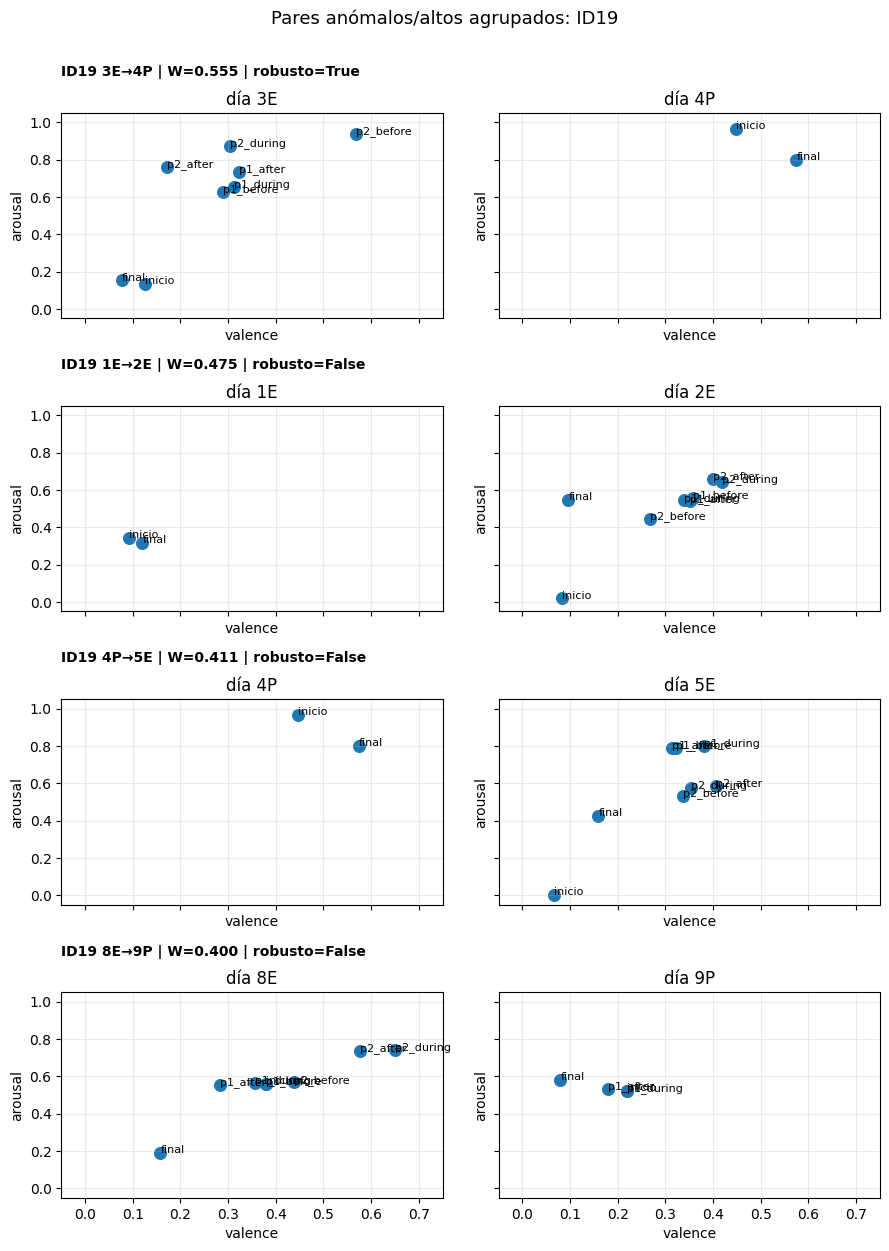

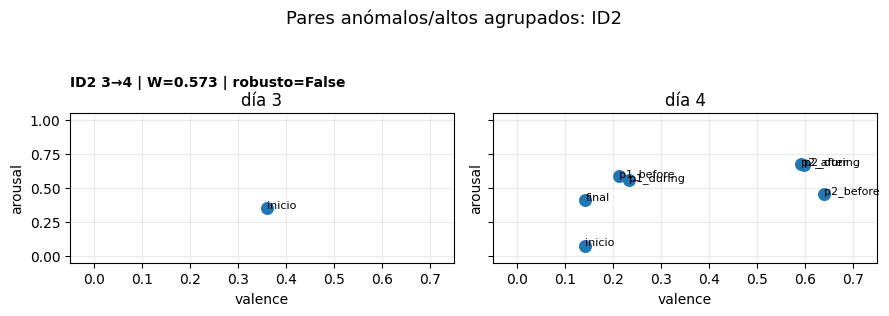

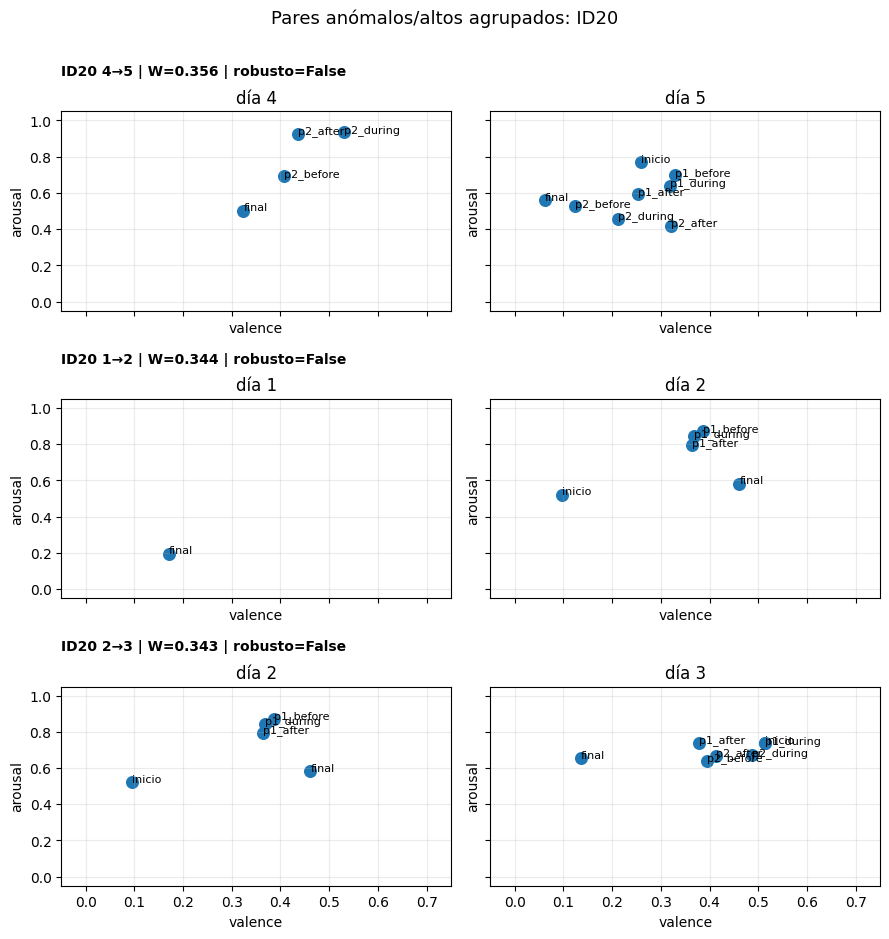

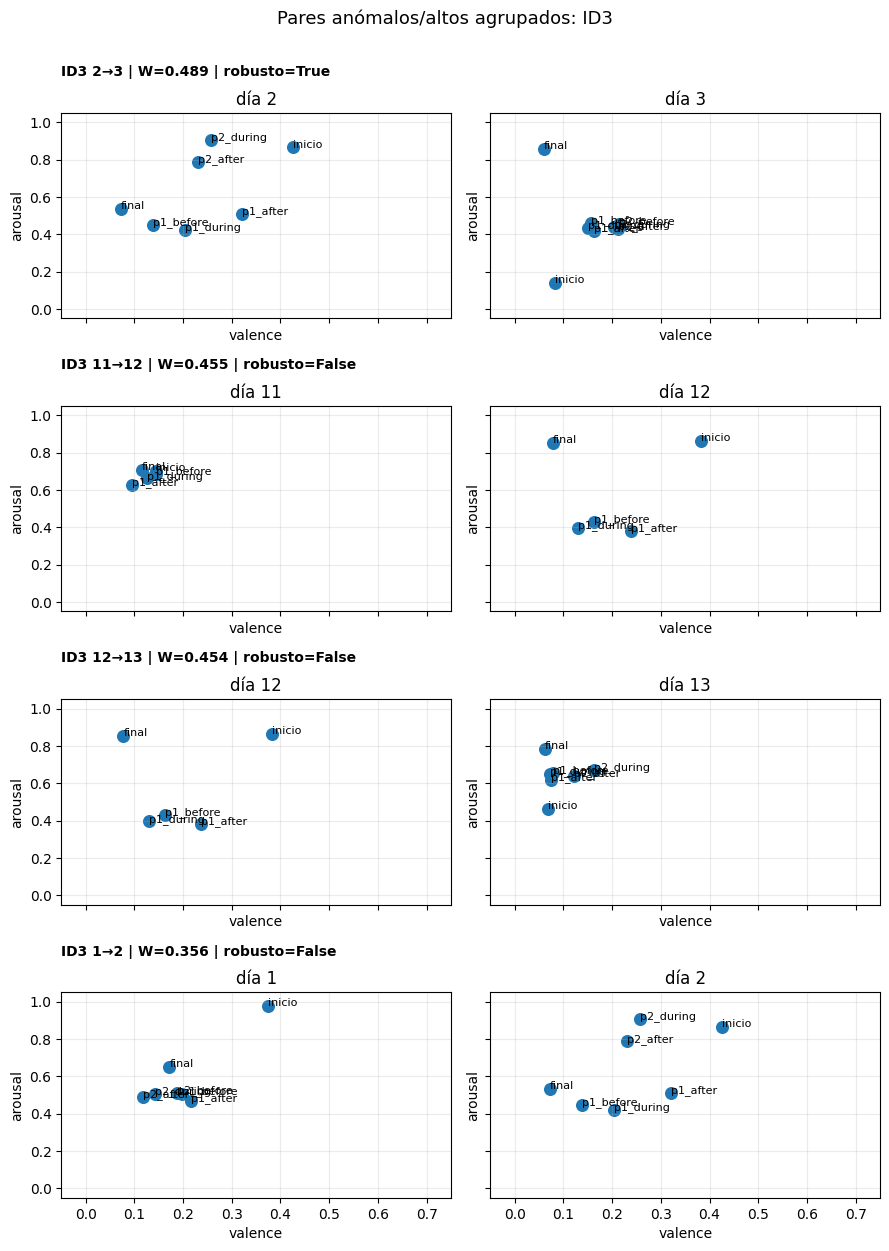

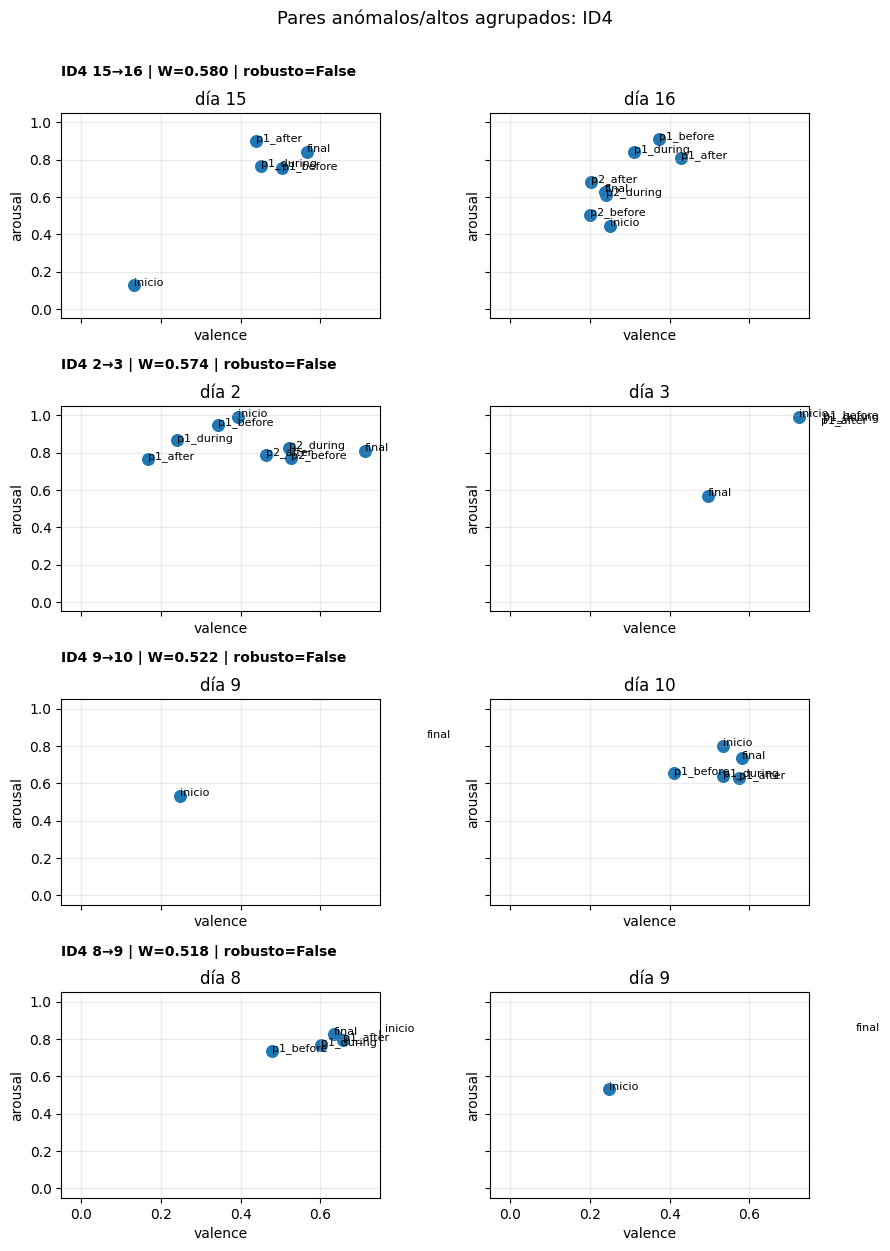

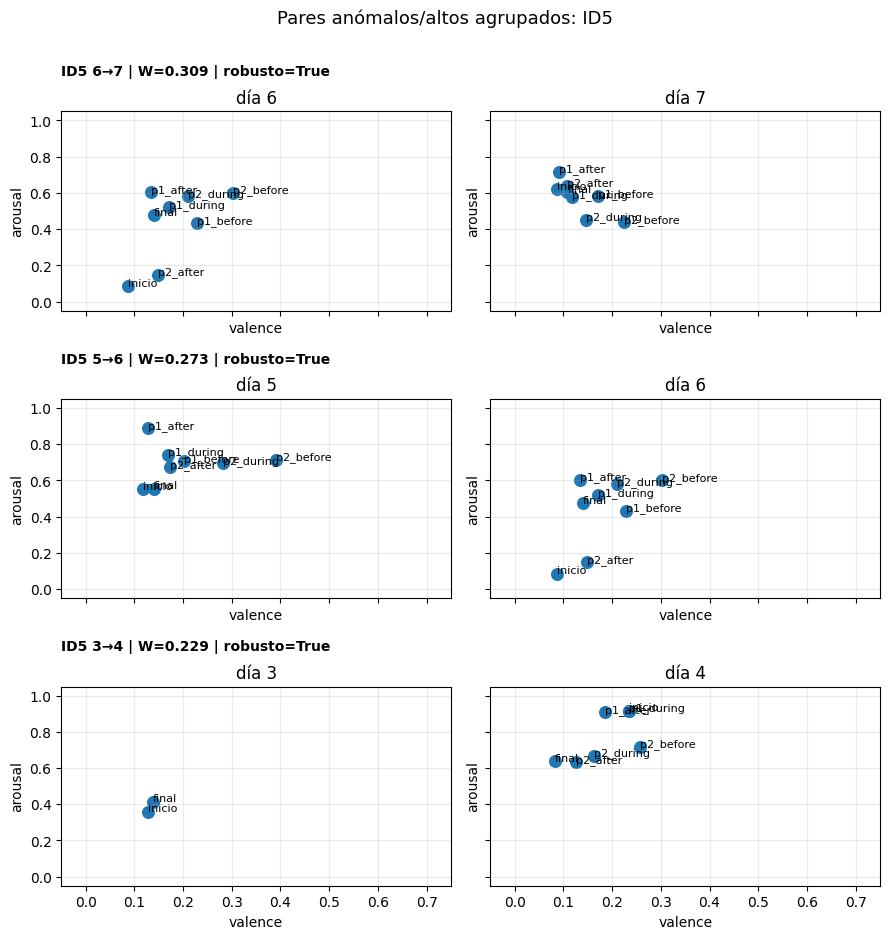

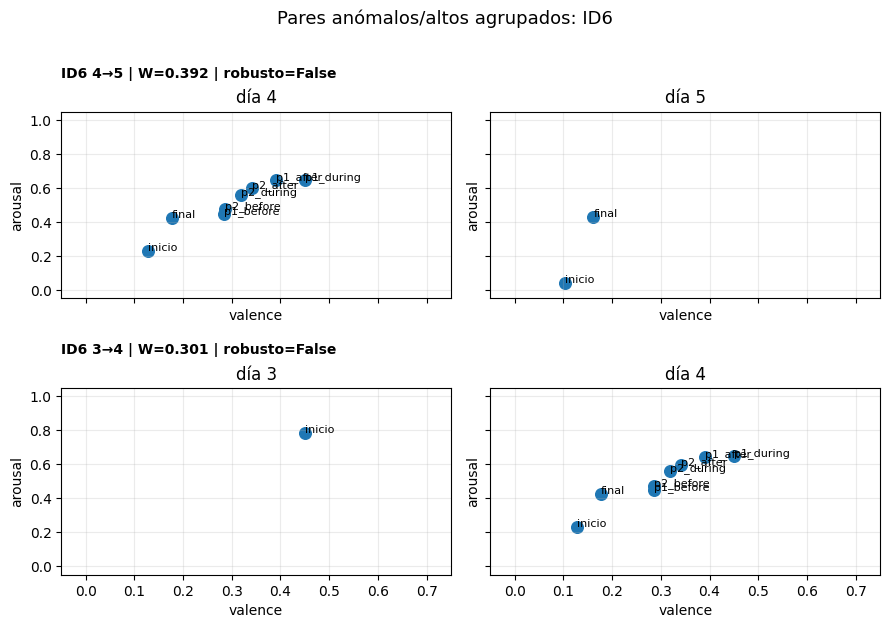

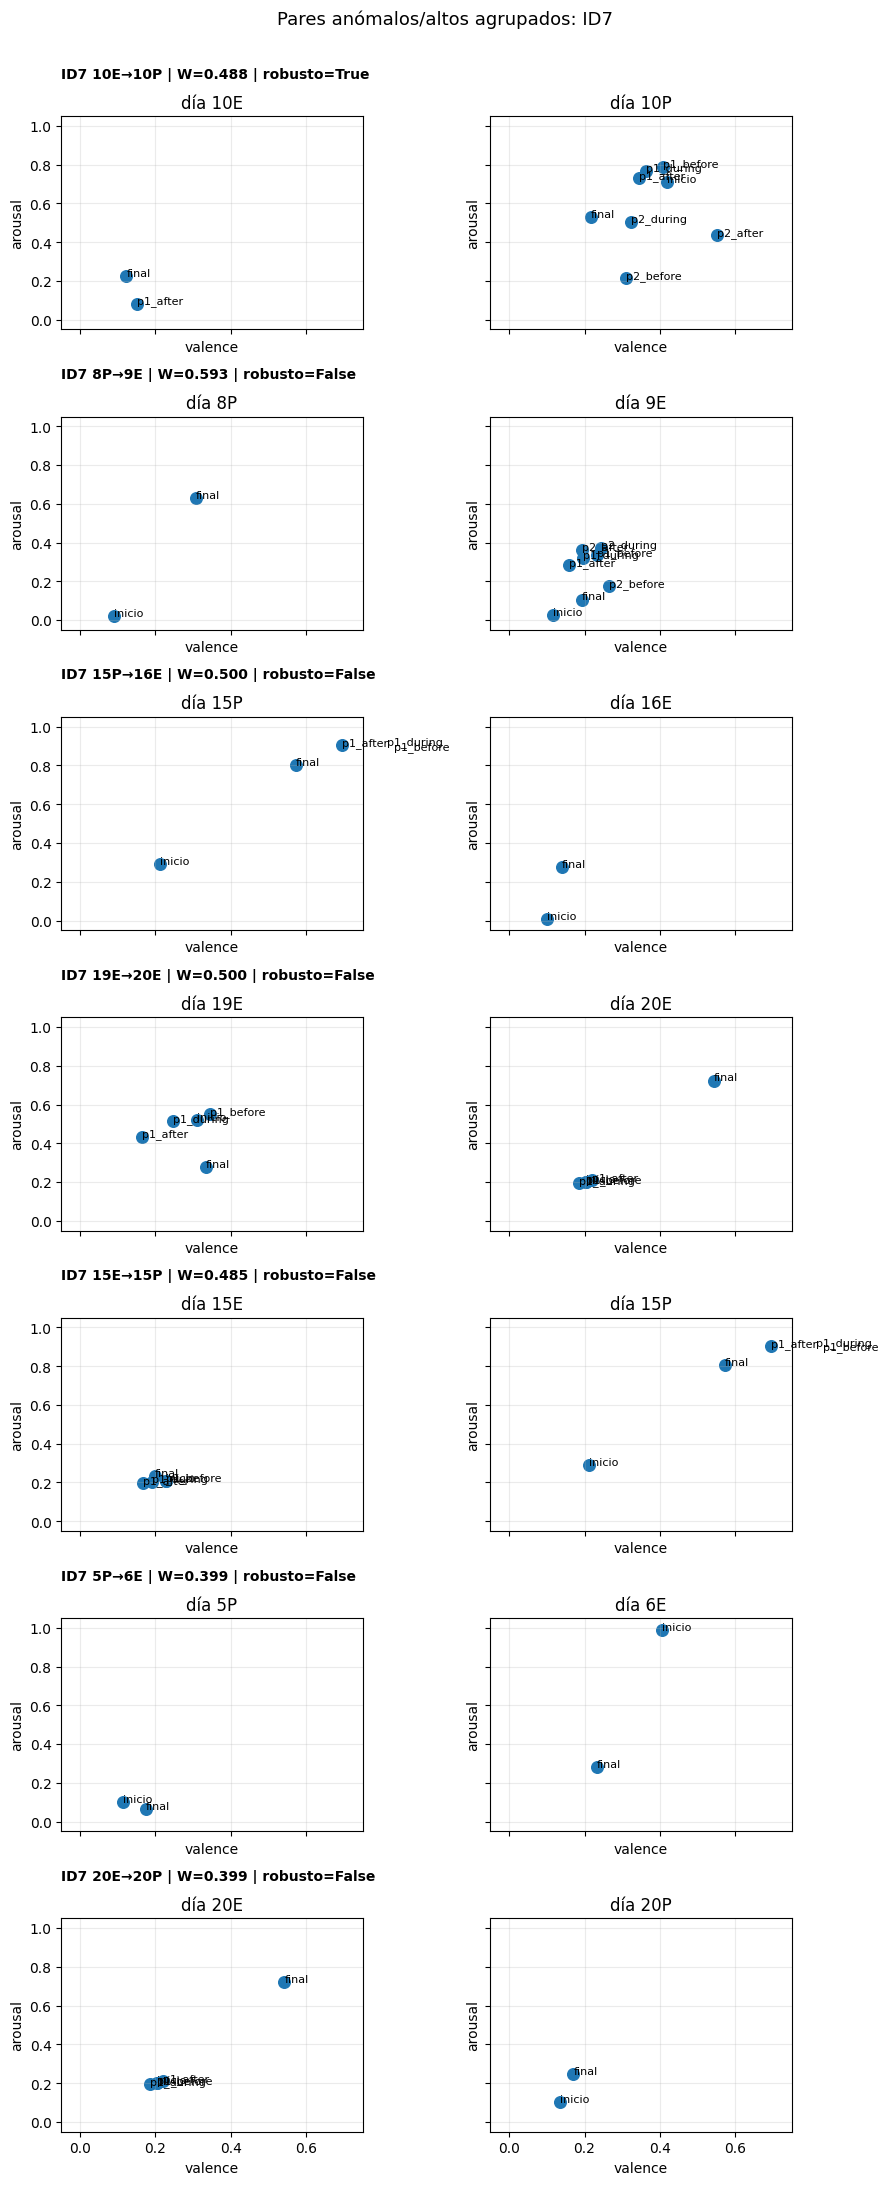

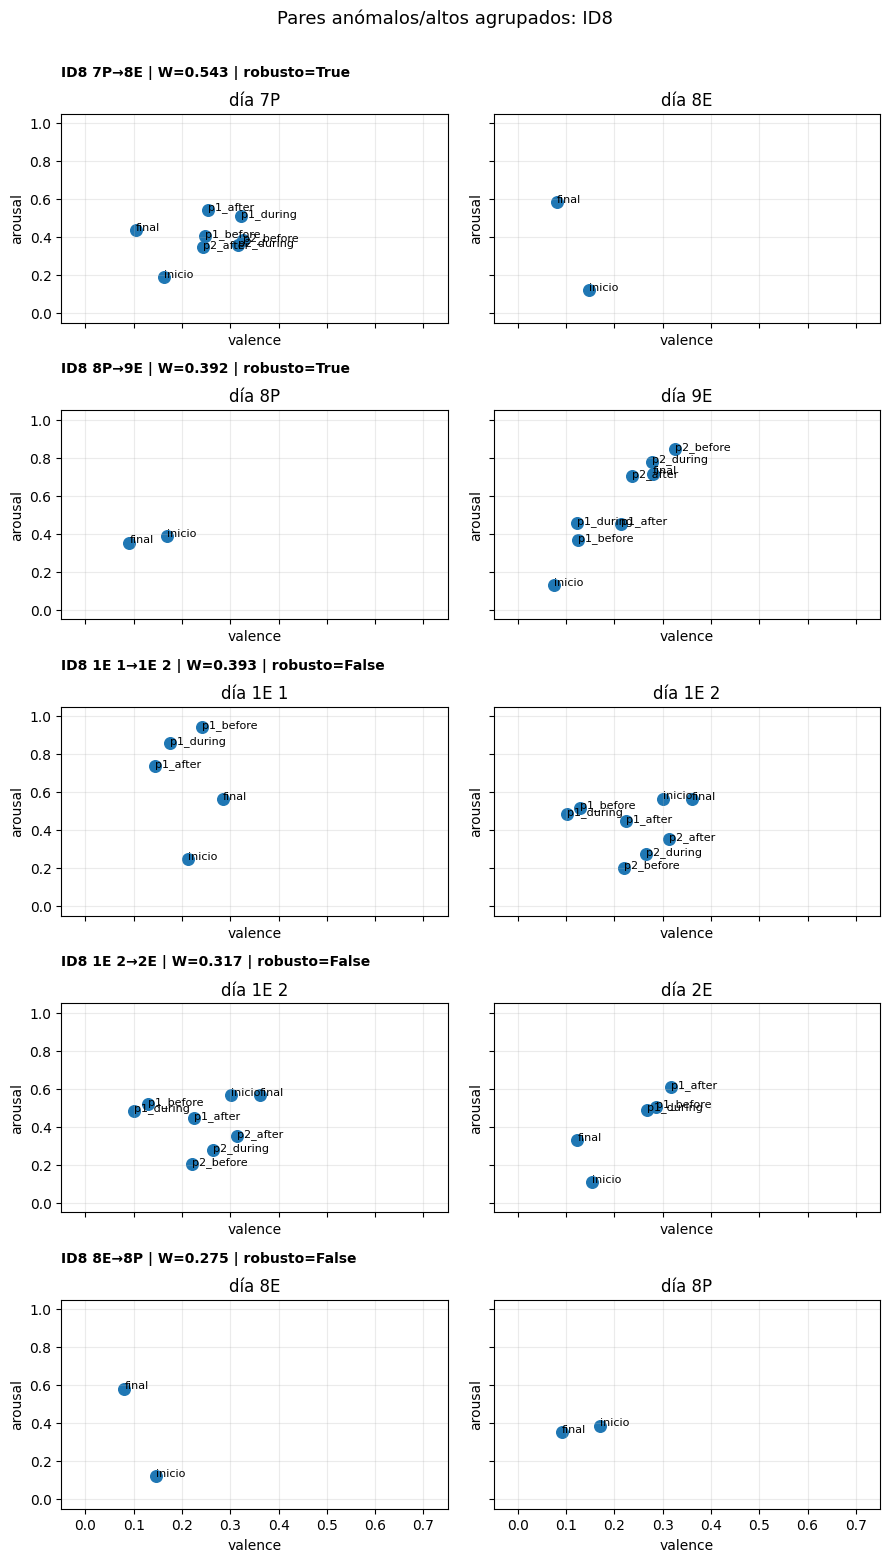

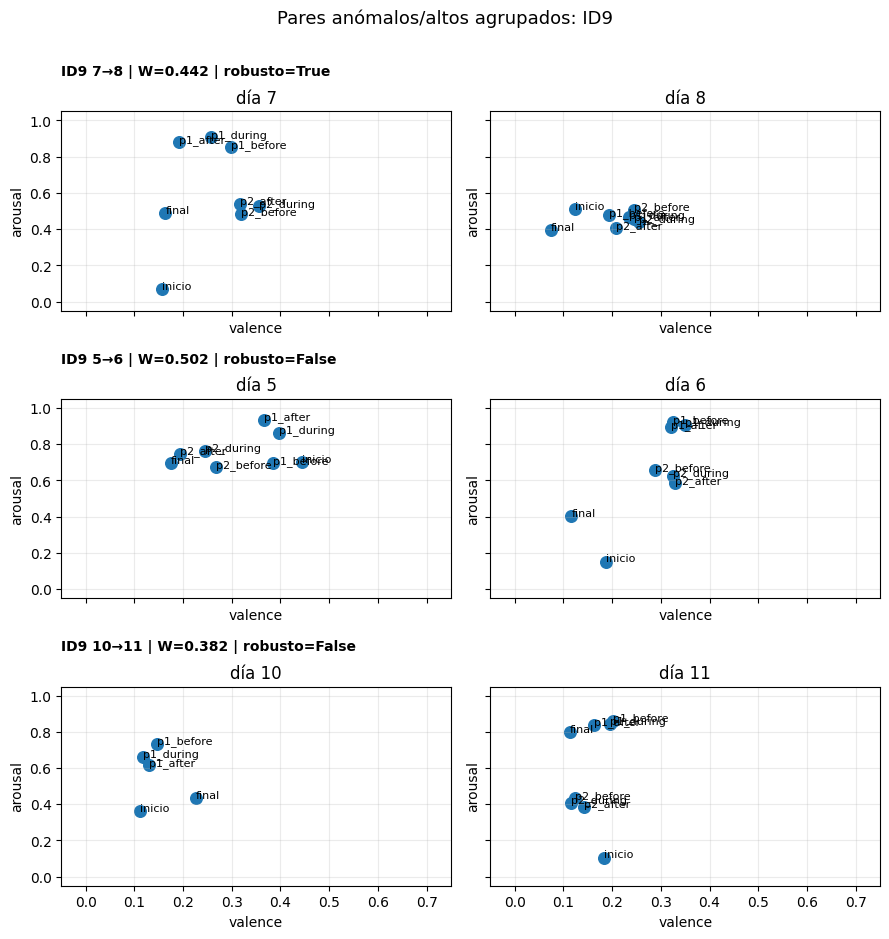

In [13]:
# Gráficas de pares anómalos/altos agrupadas por id.
# Se muestran todos los pares candidatos, no solo los primeros.
plot_candidates = trace.copy() if len(trace) else pd.DataFrame()
if len(plot_candidates):
    for kid, kid_pairs in plot_candidates.groupby('id', sort=True):
        kid_pairs = kid_pairs.sort_values(['cambio_robusto', 'wasserstein_H0'], ascending=[False, False])
        n = len(kid_pairs)
        fig, axes = plt.subplots(n, 2, figsize=(9, 3.1 * n), sharex=True, sharey=True)
        if n == 1:
            axes = np.array([axes])
        for axrow, item in zip(axes, kid_pairs.itertuples()):
            desde, hasta = item.rango_dias.split('→')
            match = boot[(boot['id'] == kid) & (boot['desde_dia'].astype(str) == desde) & (boot['hasta_dia'].astype(str) == hasta)].iloc[0]
            pair_title = f"{kid} {desde}→{hasta} | W={item.wasserstein_H0:0.3f} | robusto={bool(item.cambio_robusto)}"
            for ax, order, label in [
                (axrow[0], int(match['desde_exposicion']), f'día {desde}'),
                (axrow[1], int(match['hasta_exposicion']), f'día {hasta}')
            ]:
                cloud = clouds[(kid, order)]
                if len(cloud):
                    ax.scatter(cloud['valence'], cloud['arousal'], s=70)
                    for _, r in cloud.iterrows():
                        ax.text(r['valence'], r['arousal'], r['stage'], fontsize=8)
                ax.set_title(label)
                ax.set_xlabel('valence')
                ax.set_ylabel('arousal')
                ax.set_xlim(-0.05, 0.75)
                ax.set_ylim(-0.05, 1.05)
                ax.grid(alpha=0.25)
            axrow[0].annotate(pair_title, xy=(0, 1.18), xycoords='axes fraction', fontsize=10, weight='bold')
        fig.suptitle(f'Pares anómalos/altos agrupados: {kid}', y=1.005, fontsize=13)
        fig.tight_layout()
        safe_kid = str(kid).replace('/', '_')
        fig.savefig(OUTPUT_DIR / f'05_nubes_pares_anomalos_{safe_kid}.png', dpi=160, bbox_inches='tight')
        plt.show()
else:
    print('No se detectaron pares altos para graficar.')

## 7. Resumen final de hallazgos

In [14]:
lines = []
lines.append('# Hallazgos: persistencia por niño/día y bootstrap topológico\n')
lines.append(f'- Se analizaron los niños {", ".join(TARGET_IDS)}.')
lines.append('- Cada niño/día se representó como una nube valencia-arousal de etapas de exposición.')
lines.append('- Se usó persistencia H0 porque las nubes por día son pequeñas; H1 no sería estable con tan pocos puntos.')
lines.append(f'- Se compararon {len(distances)} pares de días consecutivos usando Wasserstein H0 como métrica principal.')
lines.append(f'- Se calculó la media agregada de Wasserstein H0 por transición usando hasta {len(TARGET_IDS)} niños.')
lines.append(f'- Se aplicó bootstrap topológico con {N_BOOT} remuestreos por par consecutivo.')
robust = boot[boot['cambio_robusto']].copy()
high = boot[boot['cambio_alto_relativo']].copy()
lines.append(f'- Pares con cambio alto relativo: {len(high)}.')
lines.append(f'- Pares con cambio robusto después de bootstrap: {len(robust)}.')
if len(robust):
    for r in robust.sort_values(METRIC_COL, ascending=False).itertuples():
        lines.append(f'  - {r.id} {r.desde_dia}→{r.hasta_dia}: wasserstein={r.wasserstein_H0:0.3f}, CI95=[{r.boot_ci_low:0.3f}, {r.boot_ci_high:0.3f}].')
elif len(high):
    top = high.sort_values(METRIC_COL, ascending=False).head(5)
    lines.append('- No todos los cambios altos son robustos bajo bootstrap; los principales candidatos para revisar son:')
    for r in top.itertuples():
        lines.append(f'  - {r.id} {r.desde_dia}→{r.hasta_dia}: wasserstein={r.wasserstein_H0:0.3f}, CI95=[{r.boot_ci_low:0.3f}, {r.boot_ci_high:0.3f}].')
lines.append('- La tabla de rastreo identifica las etapas y comentarios que explican cada cambio candidato.')

summary_text = '\n'.join(lines)
(OUTPUT_DIR / '05_hallazgos_persistencia_bootstrap.md').write_text(summary_text, encoding='utf-8')
display(Markdown(summary_text))

# Hallazgos: persistencia por niño/día y bootstrap topológico

- Se analizaron los niños ID1, ID2, ID3, ID4, ID5, ID6, ID7, ID8, ID9, ID10, ID11, ID12, ID13, ID14, ID15, ID16, ID17, ID18, ID19, ID20.
- Cada niño/día se representó como una nube valencia-arousal de etapas de exposición.
- Se usó persistencia H0 porque las nubes por día son pequeñas; H1 no sería estable con tan pocos puntos.
- Se compararon 346 pares de días consecutivos usando Wasserstein H0 como métrica principal.
- Se calculó la media agregada de Wasserstein H0 por transición usando hasta 20 niños.
- Se aplicó bootstrap topológico con 250 remuestreos por par consecutivo.
- Pares con cambio alto relativo: 76.
- Pares con cambio robusto después de bootstrap: 15.
  - ID12 12E→12P: wasserstein=0.622, CI95=[0.324, 1.373].
  - ID15 10→11: wasserstein=0.594, CI95=[0.290, 1.360].
  - ID19 3E→4P: wasserstein=0.555, CI95=[0.400, 1.262].
  - ID8 7P→8E: wasserstein=0.543, CI95=[0.263, 0.713].
  - ID3 2→3: wasserstein=0.489, CI95=[0.333, 0.910].
  - ID7 10E→10P: wasserstein=0.488, CI95=[0.342, 1.011].
  - ID12 12P→13E: wasserstein=0.481, CI95=[0.341, 1.209].
  - ID10 2E→3E: wasserstein=0.462, CI95=[0.377, 0.985].
  - ID10 6P→7E: wasserstein=0.450, CI95=[0.234, 0.780].
  - ID9 7→8: wasserstein=0.442, CI95=[0.259, 1.185].
  - ID8 8P→9E: wasserstein=0.392, CI95=[0.300, 0.861].
  - ID14 13P→14E: wasserstein=0.343, CI95=[0.306, 1.081].
  - ID5 6→7: wasserstein=0.309, CI95=[0.172, 0.721].
  - ID5 5→6: wasserstein=0.273, CI95=[0.182, 0.766].
  - ID5 3→4: wasserstein=0.229, CI95=[0.216, 0.611].
- La tabla de rastreo identifica las etapas y comentarios que explican cada cambio candidato.

In [15]:
files = sorted(OUTPUT_DIR.glob('*'))
files_df = pd.DataFrame({'archivo': [f.name for f in files], 'tamaño_kb': [round(f.stat().st_size / 1024, 1) for f in files]})
display(files_df)
print(f"Archivos guardados en: {OUTPUT_DIR.resolve()}")

,archivo,tamaño_kb
0,05_auditoria_h1_por_nino_dia.csv,25.9000
1,05_auditoria_h1_por_nino_dia.png,1179.2000
2,05_bootstrap_topologico_distancias.csv,93.7000
3,05_cobertura_nubes_por_nino_dia.csv,42.4000
4,05_diagramas_h0_por_nino_dia.png,1147.5000
5,05_distancias_h0_consecutivas_por_nino.csv,61.6000
6,05_hallazgos_persistencia_bootstrap.md,1.7000
7,05_media_wasserstein_20_ninos_por_transicion.csv,2.9000
8,05_media_wasserstein_20_ninos_por_transicion.png,180.4000
9,05_nubes_pares_anomalos.png,375.3000


Archivos guardados en: /home/jorge/Projects/topo/babyFace/persistence_child_day_outputs
